# PRAICP-1000 – Indian Sign Language Recognition

### Data Science / Deep Learning Project

**Project Reference:** PRAICP-1000  
**Project:** Indian Sign Language Recognition  
**Domain:** Computer Vision / Artificial Intelligence  

**Prepared by:** Sushameendra N Hampikar

---

## Project Introduction

Indian Sign Language (ISL) is an important form of communication used by the deaf and hard-of-hearing community. Sign language recognition using computer vision can help convert visual hand signs into understandable outputs.

This project focuses on developing an image-based machine learning model that can recognize different Indian Sign Language signs from input images.

The project begins with understanding and preprocessing the image dataset. The images will be analysed for their class distribution, dimensions, image format, image quality, and other relevant characteristics.

After completing the image preprocessing stage, a suitable deep learning model will be developed and trained to predict the corresponding sign from an input image.

## Project Goal

The primary goal of this project is to:

1. Perform image preprocessing on the Indian Sign Language dataset.
2. Develop a machine learning model to predict the corresponding sign from an input image.

## Expected Outcome

The final model should be capable of receiving an image of an Indian Sign Language hand sign and predicting the corresponding sign class.

## 1.1 Dataset Description

The dataset consists of images representing different Indian Sign Language signs. Each sign is organized into a separate directory, where the directory name represents the corresponding class label.

The dataset will be used to train a supervised image classification model capable of recognizing the sign represented in an input image.

Before model development, the dataset will be examined to understand its structure, number of classes, number of images, image dimensions, image formats, and class-wise distribution.

The actual dataset characteristics will be verified programmatically rather than assuming fixed properties before analysis.

## 1.2 Import Required Libraries

The required Python libraries are imported for dataset handling, image processing, data analysis, visualization, and deep learning model development.

The libraries will be used throughout the project for:
- Managing files and dataset directories.
- Performing numerical and tabular data analysis.
- Reading and processing images.
- Creating visualizations.
- Splitting the dataset into training, validation, and testing sets.
- Building and training the deep learning model using TensorFlow and Keras.

Only the libraries required for the project workflow are imported to keep the notebook organized and efficient.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import hashlib

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Libraries imported successfully!")
print("TensorFlow Version:", tf.__version__)

Libraries imported successfully!
TensorFlow Version: 2.20.0


### Observation

The required libraries were imported successfully, confirming that the notebook environment is ready for the upcoming dataset analysis, image processing, visualization, and deep learning steps.

The output also shows that **TensorFlow version 2.20.0** is installed and available. TensorFlow/Keras will be used later to build and train the Indian Sign Language image classification model.

**Result:** All required libraries were imported without errors.

## 1.3 Data Loading

The dataset is provided as a ZIP archive containing the Indian Sign Language image data.

In this step, the ZIP file will be located and extracted into the working directory. After extraction, the folder structure will be examined to identify the main dataset directory and the class-wise subdirectories.

Each class directory is expected to contain images belonging to the corresponding Indian Sign Language sign. The actual folder structure and available classes will be verified programmatically.

The dataset will be handled using file paths rather than loading all images into memory at once. This approach helps reduce memory usage and allows the images to be loaded in batches during the model training process.

In [5]:
import os
import subprocess

zip_path = "/content/PRAICP-1000-IndiSignLang.zip"
extract_path = "/content/ISL_Dataset"

os.makedirs(extract_path, exist_ok=True)

# Check whether 7-Zip is available
check = subprocess.run(
    ["7z", "--help"],
    capture_output=True,
    text=True
)

print("7-Zip available:", check.returncode == 0)

if check.returncode == 0:
    result = subprocess.run(
        ["7z", "x", zip_path, f"-o{extract_path}", "-y"],
        capture_output=True,
        text=True
    )

    print(result.stdout[-5000:])

    if result.returncode == 0:
        print("\nDataset extraction completed.")
    else:
        print("\n7-Zip extraction returned an error.")
        print(result.stderr)
else:
    print("7-Zip is not installed in this environment.")

7-Zip available: True

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
1 file, 84606279 bytes (81 MiB)

Extracting archive: /content/PRAICP-1000-IndiSignLang.zip
--
Path = /content/PRAICP-1000-IndiSignLang.zip
Type = zip
Physical Size = 84606279

Everything is Ok

Files: 4972
Size:       83823031
Compressed: 84606279


Dataset extraction completed.


In [6]:
# Check the extracted dataset structure

print("Extracted Dataset Structure:\n")

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    # Display only a few files from each directory
    for file in files[:5]:
        print(f"{indent}    {file}")

print("\nTotal files extracted:", sum(len(files) for _, _, files in os.walk(extract_path)))

Extracted Dataset Structure:

ISL_Dataset/
    Data/
        G/
            031.jpg
            155.jpg
            180.jpg
            228.jpg
            079.jpg
        Y/
            031.jpg
            155.jpg
            180.jpg
            228.jpg
            079.jpg
        L/
            031.jpg
            155.jpg
            180.jpg
            079.jpg
            178.jpg
        T/
            155.jpg
            180.jpg
            228.jpg
            079.jpg
            178.jpg
        N/
            031.jpg
            155.jpg
            180.jpg
            228.jpg
            079.jpg
        I/
            031.jpg
            155.jpg
            079.jpg
            178.jpg
            173.jpg
        S/
            031.jpg
            155.jpg
            180.jpg
            228.jpg
            079.jpg
        X/
            031.jpg
            155.jpg
            180.jpg
            228.jpg
            079.jpg
        U/
            031.jpg
            079.jpg
        

### Observation

The dataset was extracted successfully using 7-Zip after the standard ZIP extraction methods were unable to read the archive.

The extracted directory was then inspected using `os.walk()` to examine the folder structure and count the available files. The dataset contains a main `Data` directory, which is further divided into separate subdirectories representing the individual sign classes.

A total of **4,972 image files** were successfully extracted from the dataset.

The folder structure confirms that the images are organized class-wise, where each class directory contains the corresponding Indian Sign Language images.

**Result:** The dataset was successfully extracted and contains **4,972 image files** organized under the class-wise `Data` directory.

## 1.4 Dataset Directory and Class Identification

The extracted dataset contains a `Data` directory in which the images are organized into separate class-wise folders.

In this step, the `Data` directory will be identified programmatically and the names of all available class folders will be extracted.

The number of classes will then be calculated from the identified directories. This helps establish the target classes that the classification model will learn to recognize.

The class names and number of classes will be verified from the actual extracted dataset rather than being predefined.

In [7]:
# Define the main dataset directory
DATA_DIR = os.path.join(extract_path, "Data")

# Identify class directories
classes = sorted([
    folder
    for folder in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, folder))
])

print("Dataset Directory:", DATA_DIR)
print("Number of Classes:", len(classes))
print("Classes:", classes)

Dataset Directory: /content/ISL_Dataset/Data
Number of Classes: 24
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


### Observation

The dataset directory was identified as `/content/ISL_Dataset/Data`.

The class directories were identified by checking the folders present inside the `Data` directory and filtering only the entries that are directories. The resulting class names were then sorted alphabetically to maintain a consistent class order.

The analysis identified **24 classes**:

**A, B, C, D, E, F, G, H, I, K, L, M, N, O, P, Q, R, S, T, U, V, W, X, Y**

These class names will be used as the target labels during the image classification process.

**Result:** The dataset contains **24 identified sign classes** under the `Data` directory.

## 1.5 Class-wise Image Count Analysis

The number of images available in each sign class will be calculated to understand the distribution of images across the dataset.

In this step, each class directory will be examined and the image files will be counted based on their supported image extensions.

The class-wise image counts will help identify whether the dataset contains a similar number of images for each class or whether some classes have relatively more or fewer images.

This analysis is important before model training because differences in the number of samples between classes can affect the learning process and model performance.

In [8]:
# Count images available in each class

class_counts = {}

for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    class_counts[class_name] = len(image_files)

print("Class-wise Image Count:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

print("\nTotal Number of Images:", sum(class_counts.values()))

Class-wise Image Count:

A: 242 images
B: 259 images
C: 247 images
D: 147 images
E: 243 images
F: 226 images
G: 241 images
H: 116 images
I: 179 images
K: 245 images
L: 182 images
M: 235 images
N: 237 images
O: 229 images
P: 234 images
Q: 216 images
R: 211 images
S: 229 images
T: 216 images
U: 135 images
V: 122 images
W: 128 images
X: 202 images
Y: 251 images

Total Number of Images: 4972


### Observation

The image count for each class was calculated by iterating through all 24 class directories and counting files with the supported image extensions `.jpg`, `.jpeg`, and `.png`.

The analysis found a total of **4,972 images** across the dataset. The number of images differs between the classes.

The **B** class contains the highest number of images with **259**, while the **H** class contains the lowest number with **116** images. The remaining classes contain different numbers of images between these values.

This class-wise count analysis shows that the dataset does not contain exactly the same number of images for every class. Therefore, the class distribution will be considered during the later dataset splitting and model training stages.

**Result:** The dataset contains **4,972 images across 24 classes**, with varying numbers of images among the classes.

## 1.6 Class Distribution Visualization

A bar chart will be used to visualize the number of images available in each Indian Sign Language class.

The class names will be placed on the x-axis and the corresponding number of images on the y-axis. This visualization provides an easier way to compare the number of samples across all 24 classes.

The visualization is based on the class-wise image counts calculated in the previous step.

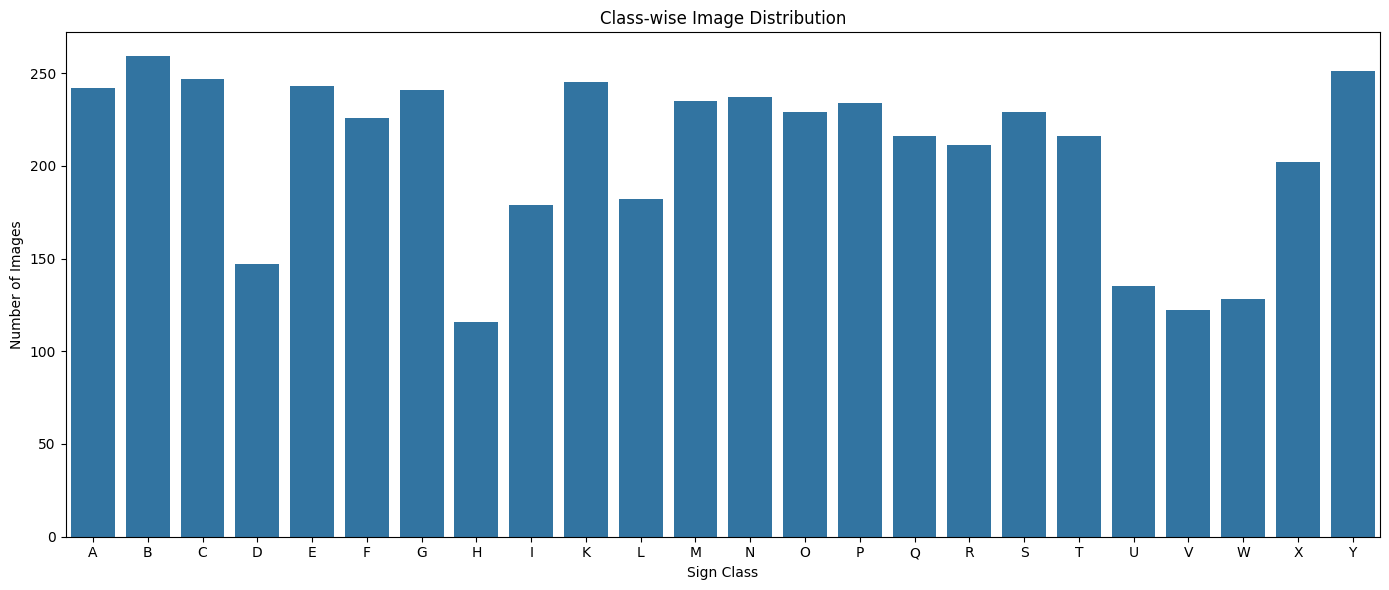

In [9]:
# Create a DataFrame from the class-wise image counts
class_distribution = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image Count"]
)

# Plot class distribution
plt.figure(figsize=(14, 6))

sns.barplot(
    data=class_distribution,
    x="Class",
    y="Image Count"
)

plt.title("Class-wise Image Distribution")
plt.xlabel("Sign Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

A bar chart was created using the class-wise image counts to visually compare the number of images available for each Indian Sign Language class.

The visualization shows that the image counts vary across the 24 classes. The **B** class has the tallest bar, representing the highest number of images, while the **H** class has the shortest bar, representing the lowest number of images.

Several classes such as **A, C, E, G, K, M, N, O, P, S, and Y** have relatively higher image counts, while classes such as **D, H, U, V, and W** have comparatively fewer images.

This visualization makes the variation in class-wise sample sizes easier to identify and confirms that the dataset is not perfectly balanced across all classes.

**Result:** The class distribution visualization confirms variation in the number of images among the 24 sign classes.

## 1.7 Image Format Analysis

The image file extensions present in the dataset will be analysed to determine the formats used for storing the sign language images.

In this step, all class directories will be examined and the file extensions of the image files will be extracted. The extensions will then be counted to determine the number of images available in each format.

This analysis helps verify the consistency of the dataset's image file format before the image preprocessing and model training stages.

In [10]:
from collections import Counter

# Collect image file extensions
image_extensions = []

for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            extension = os.path.splitext(file)[1].lower()
            image_extensions.append(extension)

# Count each image format
extension_counts = Counter(image_extensions)

print("Image Format Distribution:\n")

for extension, count in sorted(extension_counts.items()):
    print(f"{extension}: {count} images")

print("\nTotal Images Analysed:", len(image_extensions))

Image Format Distribution:

.jpg: 4972 images

Total Images Analysed: 4972


### Observation

The image file format was analysed by examining the file extension of each image present in all 24 class directories.

The analysis identified **4,972 image files**, and all **4,972 images are stored in `.jpg` format**. No other supported image formats such as `.jpeg` or `.png` were found in the dataset.

Using a single image format provides consistency in the dataset and simplifies the image loading and preprocessing process in the subsequent stages.

**Result:** All **4,972 images** in the dataset are available in **`.jpg` format**.

## 1.8 Image Dimension Analysis

The dimensions of the images will be analysed to determine whether all images have the same height and width.

In this step, each image will be opened using the PIL library and its width and height will be recorded. The collected dimensions will then be counted to identify the different image sizes present in the dataset.

Understanding the image dimensions is important because deep learning models require images to be provided in a consistent input size. If different dimensions are present, the images will need to be resized during the preprocessing stage.

In [11]:
from collections import Counter

# Collect image dimensions
image_dimensions = []

for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(class_path, file)

            try:
                with Image.open(image_path) as img:
                    image_dimensions.append(img.size)
            except Exception:
                pass

# Count each dimension
dimension_counts = Counter(image_dimensions)

print("Image Dimension Distribution:\n")

for dimension, count in dimension_counts.items():
    print(f"{dimension}: {count} images")

print("\nNumber of images analysed:", len(image_dimensions))
print("Number of unique dimensions:", len(dimension_counts))

Image Dimension Distribution:

(640, 480): 3963 images
(1920, 1088): 830 images
(1088, 1920): 179 images

Number of images analysed: 4972
Number of unique dimensions: 3


### Observation

The image dimensions were analysed by opening each image using the PIL library and recording its width and height. The collected dimensions were then counted to identify the different image sizes present in the dataset.

A total of **4,972 images** were analysed, and **3 unique image dimensions** were identified:

- **(640, 480):** 3,963 images
- **(1920, 1088):** 830 images
- **(1088, 1920):** 179 images

The results show that the images do not all have the same dimensions. Therefore, a common image size will be required during the preprocessing stage so that all images can be provided with a consistent input shape to the deep learning model.

**Result:** The dataset contains **3 different image dimensions**, with **(640, 480)** being the most common dimension.

## 1.9 Image Color Mode and Channel Analysis

The color mode of the images will be analysed to determine how the image data is represented.

In this step, each image will be opened using the PIL library and its color mode will be recorded. The color mode will help identify the number of color channels that need to be handled during image preprocessing.

This analysis is important for determining the appropriate input format for the deep learning model.

In [12]:
# Analyse image color modes

image_modes = []

for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(class_path, file)

            try:
                with Image.open(image_path) as img:
                    image_modes.append(img.mode)
            except Exception:
                pass

# Count each image mode
mode_counts = Counter(image_modes)

print("Image Color Mode Distribution:\n")

for mode, count in mode_counts.items():
    print(f"{mode}: {count} images")

print("\nTotal Images Analysed:", len(image_modes))

Image Color Mode Distribution:

RGB: 4972 images

Total Images Analysed: 4972


### Observation

The image color mode was analysed by opening each image using the PIL library and recording its color mode. The collected modes were then counted to determine the color representation used across the dataset.

All **4,972 images** were identified as **RGB** images.

An RGB image contains three color channels: Red, Green, and Blue. Therefore, the images can be processed as three-channel color images during the preprocessing and model development stages.

**Result:** All **4,972 images** in the dataset are in **RGB color mode**.

## 1.10 Duplicate Image Analysis

Duplicate images will be identified to check whether the dataset contains repeated image files.

In this step, the binary content of each image file will be read and an MD5 hash will be generated for each image. Images producing the same hash will be treated as duplicate files because their binary content is identical.

The duplicate analysis helps identify repeated images before the dataset is divided into training, validation, and testing sets. This is important because duplicate images across different datasets could lead to data leakage and affect the reliability of model evaluation.

The analysis will be performed using file-level hashing without loading the complete image dataset into memory.

In [13]:
# Identify duplicate images using MD5 hashing

image_hashes = {}
duplicate_images = []

for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            image_path = os.path.join(class_path, file)

            with open(image_path, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            if file_hash in image_hashes:
                duplicate_images.append(
                    (image_path, image_hashes[file_hash])
                )
            else:
                image_hashes[file_hash] = image_path

print("Total images checked:", len(image_hashes) + len(duplicate_images))
print("Number of duplicate images:", len(duplicate_images))

if duplicate_images:
    print("\nDuplicate image files:")
    for duplicate, original in duplicate_images:
        print("Duplicate:", duplicate)
        print("Original :", original)

Total images checked: 4972
Number of duplicate images: 1

Duplicate image files:
Duplicate: /content/ISL_Dataset/Data/I/002.jpg
Original : /content/ISL_Dataset/Data/I/001.jpg


### Observation

Duplicate image analysis was performed by reading the binary content of each image and generating an MD5 hash for each file. The generated hash values were compared to identify images with identical file content.

A total of **4,972 images** were checked during the analysis. The result identified **1 duplicate image**.

The duplicate file was:

- **Duplicate:** `/content/ISL_Dataset/Data/I/002.jpg`
- **Original:** `/content/ISL_Dataset/Data/I/001.jpg`

Both files produced the same MD5 hash, indicating that their binary image contents are identical.

**Result:** The dataset contains **1 duplicate image**, which should be considered before creating the training, validation, and testing datasets.

## 1.11 Image Quality and Corruption Analysis

The dataset will be checked for invalid, corrupted, or unreadable image files before proceeding with model development.

In this step, each image will be opened using the PIL library and verified using the `verify()` method. Images that cannot be opened or verified successfully will be recorded as invalid or corrupted.

This validation helps ensure that only readable and valid image files are used during the preprocessing and model training stages.

In [14]:
# Check for invalid or corrupted images

invalid_images = []
total_checked = 0

for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            image_path = os.path.join(class_path, file)
            total_checked += 1

            try:
                with Image.open(image_path) as img:
                    img.verify()

            except Exception:
                invalid_images.append(image_path)

print("Total images checked:", total_checked)
print("Number of invalid/corrupted images:", len(invalid_images))

if invalid_images:
    print("\nInvalid/Corrupted image files:")
    for image_path in invalid_images:
        print(image_path)

Total images checked: 4972
Number of invalid/corrupted images: 0


### Observation

Image quality validation was performed by opening each image using the PIL library and applying the `verify()` method to check whether the image files could be successfully read and verified.

A total of **4,972 images** were checked during the validation process. The analysis identified **0 invalid or corrupted images**.

This indicates that all the checked image files passed the image verification process and can proceed to the subsequent preprocessing stages.

**Result:** All **4,972 images** passed the image quality validation, with **0 invalid or corrupted images** detected.

## 1.12 Image Visualization

Sample images from each sign class will be visualized to understand the visual characteristics of the dataset.

In this step, one representative image will be selected from each of the 24 class directories and displayed in a grid. The corresponding class name will be shown as the title of each image.

This visualization helps examine the different hand-sign patterns and provides an initial understanding of the visual variations present across the sign classes.

The images will be loaded one at a time for visualization rather than loading the complete dataset into memory.

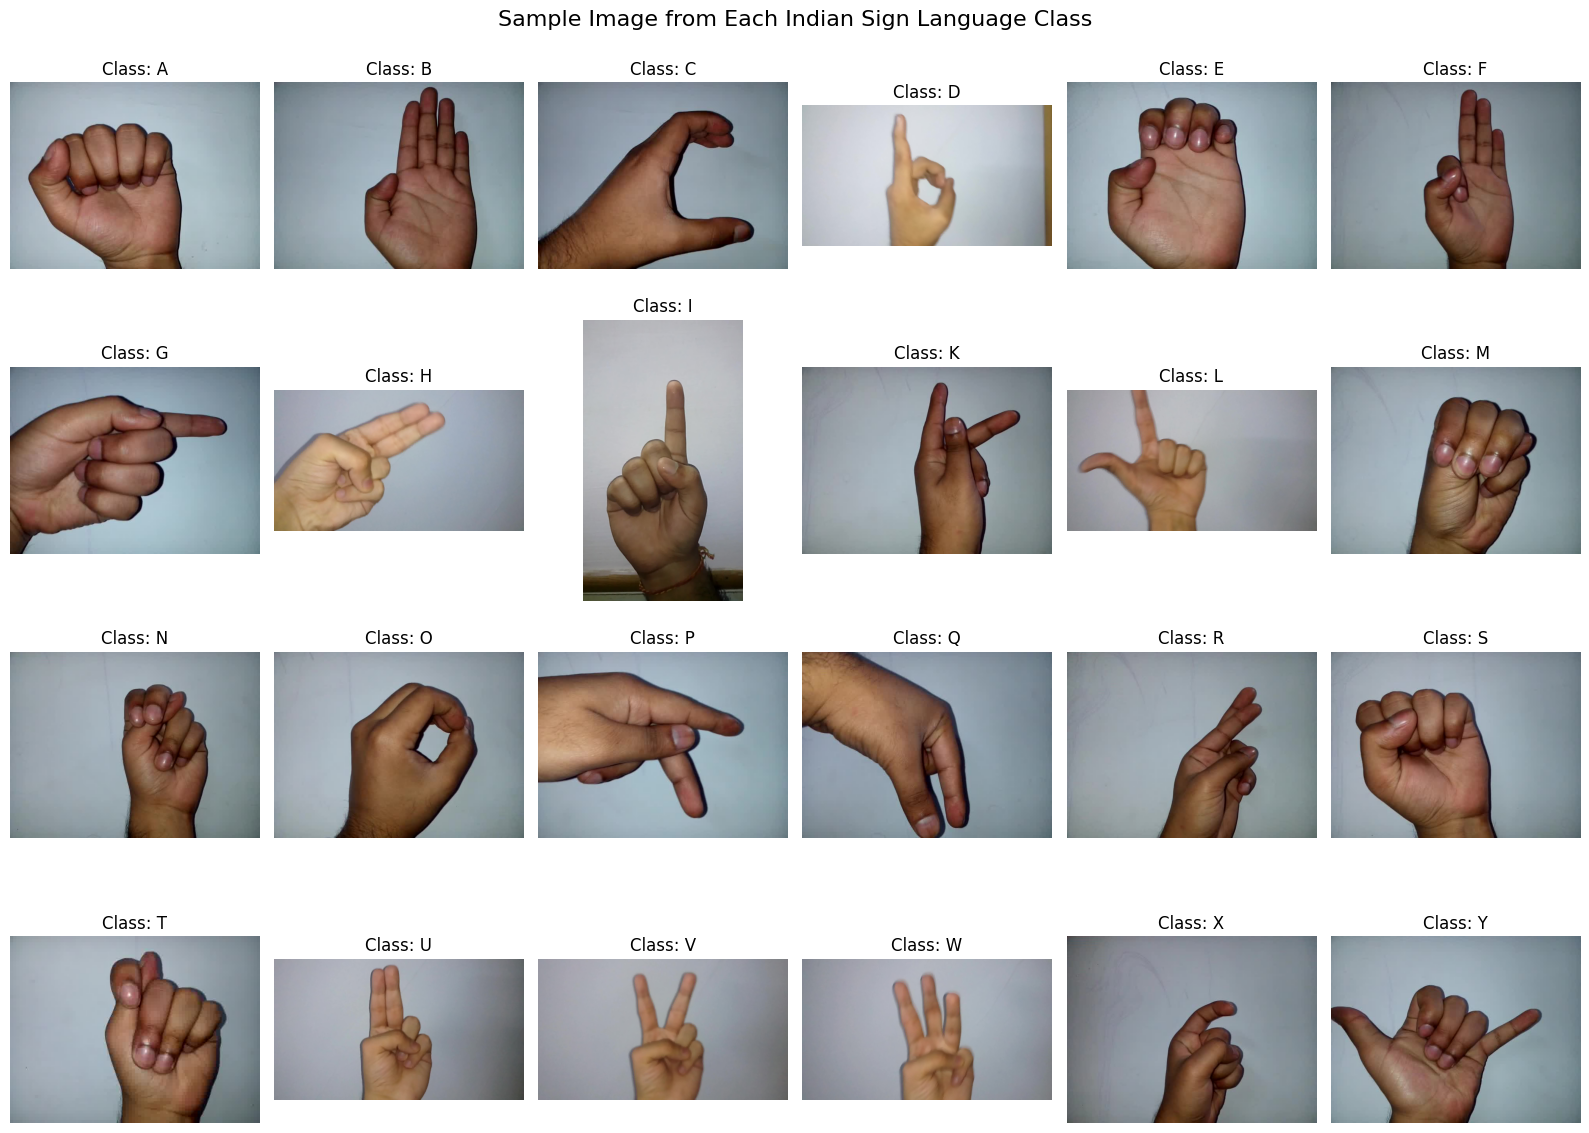

In [15]:
# Visualize one sample image from each class

fig, axes = plt.subplots(4, 6, figsize=(16, 12))
axes = axes.flatten()

for index, class_name in enumerate(classes):

    class_path = os.path.join(DATA_DIR, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Select the first available image
    sample_image_path = os.path.join(class_path, image_files[0])

    # Open image for visualization
    with Image.open(sample_image_path) as img:
        axes[index].imshow(img.convert("RGB"))

    axes[index].set_title(f"Class: {class_name}")
    axes[index].axis("off")

plt.suptitle("Sample Image from Each Indian Sign Language Class", fontsize=16)
plt.tight_layout()
plt.show()

### Observation

One sample image from each of the 24 sign classes was selected and displayed in a 4 × 6 grid using Matplotlib. The class name was added as the title above each corresponding image.

The visualization shows that the classes contain different hand-sign patterns, with variations in finger positions, hand shapes, and orientations. The images also show differences in the position and size of the hand within the image.

These visual variations indicate that the model will need to learn the relevant hand-sign patterns while handling differences in image appearance and positioning.

**Result:** The sample visualization confirms that the dataset contains visually different hand-sign patterns across the 24 identified classes, along with variations in hand position, shape, and orientation.

## 1.13 Pixel Value Analysis

The pixel values of a sample image will be analysed to understand how the image data is represented before preprocessing.

In this step, one image will be selected from the dataset and converted into a NumPy array. The minimum and maximum pixel values, image shape, and data type will then be examined.

For RGB images, pixel values are represented separately for the Red, Green, and Blue channels. Understanding these values is useful before applying normalization during the preprocessing stage.

In [16]:
# Select one sample image for pixel value analysis

sample_class = classes[0]
sample_class_path = os.path.join(DATA_DIR, sample_class)

sample_image_file = [
    file for file in os.listdir(sample_class_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
][0]

sample_image_path = os.path.join(sample_class_path, sample_image_file)

# Open the sample image and convert it into a NumPy array
with Image.open(sample_image_path) as img:
    sample_image = img.convert("RGB")
    image_array = np.array(sample_image)

print("Sample Class:", sample_class)
print("Sample Image:", sample_image_file)
print("Image Shape:", image_array.shape)
print("Minimum Pixel Value:", image_array.min())
print("Maximum Pixel Value:", image_array.max())
print("Data Type:", image_array.dtype)

Sample Class: A
Sample Image: 031.jpg
Image Shape: (480, 640, 3)
Minimum Pixel Value: 0
Maximum Pixel Value: 226
Data Type: uint8


### Observation

A sample image from class **A** (`031.jpg`) was selected and converted into a NumPy array to analyse its pixel-level properties.

The image shape was found to be **(480, 640, 3)**, indicating a height of 480 pixels, a width of 640 pixels, and 3 color channels corresponding to the RGB format.

The minimum pixel value was **0**, while the maximum pixel value was **226**. The image data type was **uint8**, which represents the pixel values in an integer format.

This analysis provides the baseline pixel representation before normalization is applied during image preprocessing.

**Result:** The selected sample image is an RGB image with shape **(480, 640, 3)** and pixel values ranging from **0 to 226**, stored as **uint8**.

## 1.14 Dataset Summary

A consolidated summary of the dataset analysis performed so far will be created to record the main characteristics identified during the exploratory data analysis.

The summary will include the dataset location, total number of images, number of classes, image format, image color mode, number of unique image dimensions, number of duplicate images, and number of invalid or corrupted images.

This summary provides a clear overview of the dataset before beginning the image preprocessing and dataset preparation stages.

In [17]:
# Create a consolidated dataset summary

print("========== DATASET SUMMARY ==========")
print("Dataset Path:", DATA_DIR)
print("Total Number of Images:", len(image_extensions))
print("Number of Classes:", len(classes))
print("Image Format: .jpg")
print("Image Mode: RGB")
print("Unique Image Dimensions:", len(dimension_counts))
print("Duplicate Images:", len(duplicate_images))
print("Invalid/Corrupted Images:", len(invalid_images))
print("=====================================")

========== DATASET SUMMARY ==========
Dataset Path: /content/ISL_Dataset/Data
Total Number of Images: 4972
Number of Classes: 24
Image Format: .jpg
Image Mode: RGB
Unique Image Dimensions: 3
Duplicate Images: 1
Invalid/Corrupted Images: 0


### Observation

A consolidated dataset summary was created using the results obtained from the previous analysis steps.

The dataset is located at `/content/ISL_Dataset/Data` and contains **4,972 images** belonging to **24 classes**. All images are stored in **`.jpg` format** and use the **RGB** color mode.

The dimension analysis identified **3 unique image dimensions**, showing that the images do not have a uniform size. The duplicate analysis identified **1 duplicate image**, while the image quality validation found **0 invalid or corrupted images**.

These findings provide the required understanding of the dataset structure and quality before proceeding with image preprocessing.

**Result:** The dataset contains **4,972 valid RGB `.jpg` images across 24 classes**, with **3 different image dimensions**, **1 duplicate image**, and **0 corrupted images**.

# 2. Image Preprocessing

Image preprocessing is an important step in preparing the Indian Sign Language images for deep learning model development.

The dataset contains images with different dimensions, while the classification model requires a consistent input image size. Therefore, the images will be resized to a fixed height and width during the data loading process.

The images will also be converted into numerical tensor representations and normalized so that the pixel values are scaled to a suitable range for deep learning.

The dataset will be divided into training, validation, and testing sets. The images will be loaded in batches instead of storing the complete image dataset in memory, which helps maintain efficient memory usage during model development and training.

The preprocessing pipeline will include:

1. Defining the target image size and batch size.
2. Creating a list of image file paths and their corresponding class labels.
3. Splitting the image paths into training, validation, and testing datasets.
4. Loading and resizing images when required.
5. Normalizing pixel values.
6. Creating batch-based TensorFlow datasets.
7. Applying data augmentation to the training data where appropriate.

## 2.1 Image Size and Batch Configuration

A fixed image size will be defined so that all images can be provided to the deep learning model with a consistent input shape.

The target image dimensions are set to **224 × 224 pixels**. Since the dataset contains RGB images, each processed image will have three color channels.

A batch size of **32** will be used to load and process the images in smaller groups. This batch-based approach avoids loading the complete image dataset into memory and provides a more efficient pipeline for model training.

The selected image size and batch size will be used throughout the subsequent preprocessing and training stages.

In [18]:
# Define image preprocessing parameters

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

print("Image Height:", IMG_HEIGHT)
print("Image Width:", IMG_WIDTH)
print("Batch Size:", BATCH_SIZE)

Image Height: 224
Image Width: 224
Batch Size: 32


### Observation

The image preprocessing parameters were defined by setting the target image height and width to **224 × 224 pixels** and the batch size to **32**.

The fixed image size will ensure that all images have a consistent input shape when they are loaded for model development. The batch size of 32 will allow the images to be processed in smaller groups instead of loading the complete dataset into memory at once.

These parameters will be used in the subsequent image loading and preprocessing pipeline.

**Result:** The preprocessing configuration is set to an image size of **224 × 224 pixels** with a **batch size of 32**.

## 2.2 Create Image File Paths and Labels

Instead of loading all images into memory, the file paths of the images will be collected along with their corresponding class labels.

Each image path will be associated with the name of the directory in which the image is stored. The class name will therefore act as the target label for supervised learning.

The file paths and labels will be stored in a Pandas DataFrame. This DataFrame contains only file locations and label information, making it significantly more memory-efficient than storing the complete image arrays.

This DataFrame will later be used to create stratified training, validation, and testing datasets.

In [19]:
# Create image file paths and corresponding class labels

image_paths = []
image_labels = []

for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(class_path, file))
            image_labels.append(class_name)

# Create DataFrame
image_df = pd.DataFrame({
    "image_path": image_paths,
    "label": image_labels
})

print("Total Images:", len(image_df))
print("Total Classes:", image_df["label"].nunique())

print("\nFirst 5 Records:")
display(image_df.head())

Total Images: 4972
Total Classes: 24

First 5 Records:


,image_path,label
0,/content/ISL_Dataset/Data/A/031.jpg,A
1,/content/ISL_Dataset/Data/A/155.jpg,A
2,/content/ISL_Dataset/Data/A/180.jpg,A
3,/content/ISL_Dataset/Data/A/228.jpg,A
4,/content/ISL_Dataset/Data/A/079.jpg,A


### Observation

The image file paths and their corresponding class labels were collected by iterating through each of the 24 class directories. For every supported image file, its complete file path was stored along with the class name obtained from its directory.

The resulting Pandas DataFrame contains **4,972 image records** and represents **24 unique classes**. The first five records belong to class **A**, with their corresponding image paths stored in the `image_path` column and the class name stored in the `label` column.

Storing file paths and labels instead of complete image arrays keeps the dataset representation memory-efficient. The DataFrame will be used in the next step to create the training, validation, and testing datasets.

**Result:** A memory-efficient DataFrame containing **4,972 image paths and their corresponding labels across 24 classes** was successfully created.

## 2.3 Train, Validation, and Test Split

The image paths and corresponding labels will be divided into training, validation, and testing datasets.

The dataset will first be divided into **80% training and 20% temporary testing data**. The temporary testing data will then be divided equally to create the final **10% validation and 10% testing datasets**.

Stratified splitting will be used so that the distribution of the 24 sign classes is maintained as consistently as possible across the training, validation, and testing datasets.

A fixed random state will be used to make the splitting process reproducible.

Only the image paths and labels are being split at this stage. The actual image data will be loaded later in batches, which helps avoid unnecessary memory usage.

In [20]:
# First split: 80% training and 20% temporary data
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.20,
    random_state=42,
    stratify=image_df["label"]
)

# Second split: divide the temporary data equally
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

# Reset DataFrame indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training Images:", len(train_df))
print("Validation Images:", len(val_df))
print("Testing Images:", len(test_df))

print("\nTotal Images:", len(train_df) + len(val_df) + len(test_df))

Training Images: 3977
Validation Images: 497
Testing Images: 498

Total Images: 4972


### Observation

The dataset was divided into training, validation, and testing sets using a two-step stratified splitting process.

First, **80% of the dataset** was allocated to the training set and **20%** was retained as temporary data. The temporary data was then divided equally into validation and testing sets.

The resulting split contains:

- **Training:** 3,977 images
- **Validation:** 497 images
- **Testing:** 498 images
- **Total:** 4,972 images

Stratification was applied during both splitting stages so that the class distribution of the 24 sign classes could be maintained across the different datasets.

**Result:** The complete dataset of **4,972 images** was successfully divided into training, validation, and testing sets without loading the image data into memory.

## 2.4 Class Distribution After Data Splitting

The class distribution in the training, validation, and testing datasets will be analysed after the data split.

In this step, the number of images belonging to each sign class will be calculated separately for the three datasets. The results will be combined into a single DataFrame for comparison.

This analysis verifies whether all 24 classes are represented across the training, validation, and testing datasets and whether the stratified splitting process has maintained a similar class distribution.

The analysis uses only the file paths and labels stored in the DataFrames, so the image files do not need to be loaded into memory.

In [21]:
# Calculate class distribution for each dataset split

train_class_counts = train_df["label"].value_counts().reindex(classes, fill_value=0)
val_class_counts = val_df["label"].value_counts().reindex(classes, fill_value=0)
test_class_counts = test_df["label"].value_counts().reindex(classes, fill_value=0)

# Create comparison DataFrame
split_distribution = pd.DataFrame({
    "Class": classes,
    "Training": train_class_counts.values,
    "Validation": val_class_counts.values,
    "Testing": test_class_counts.values
})

display(split_distribution)

print("Training Images:", split_distribution["Training"].sum())
print("Validation Images:", split_distribution["Validation"].sum())
print("Testing Images:", split_distribution["Testing"].sum())

,Class,Training,Validation,Testing
0,A,193,24,25
1,B,207,26,26
2,C,197,25,25
3,D,118,15,14
4,E,194,24,25
5,F,181,22,23
6,G,193,24,24
7,H,93,12,11
8,I,143,18,18
9,K,196,24,25


Training Images: 3977
Validation Images: 497
Testing Images: 498


### Observation

The class distribution was analysed separately for the training, validation, and testing datasets after the stratified splitting process.

The results show that all **24 classes are represented in each of the three datasets**. The training set contains **3,977 images**, the validation set contains **497 images**, and the testing set contains **498 images**.

The number of samples for each class varies across the datasets, while the relative distribution of the classes is maintained between the training, validation, and testing sets.

This confirms that the stratified splitting process has distributed the available samples across the three datasets while retaining

## 2.5 Remove Duplicate Image Before Model Training

During the dataset quality analysis, one exact duplicate image was identified in class **I**.

The duplicate image should be removed before the final training, validation, and testing datasets are created. This helps prevent the same image content from being present in more than one dataset, which could lead to data leakage and produce an overly optimistic evaluation of the model.

The identified duplicate is:

- Duplicate: `/content/ISL_Dataset/Data/I/002.jpg`
- Original: `/content/ISL_Dataset/Data/I/001.jpg`

The duplicate image will be removed from the main image DataFrame, and the train-validation-test split will then be recreated using the remaining images.

The same stratified **80% training, 10% validation, and 10% testing** approach will be used again with `random_state=42`.

In [22]:
# Path of the identified duplicate image
duplicate_path = "/content/ISL_Dataset/Data/I/002.jpg"

# Remove the duplicate image
image_df_clean = image_df[
    image_df["image_path"] != duplicate_path
].reset_index(drop=True)

print("Original Images:", len(image_df))
print("Images After Duplicate Removal:", len(image_df_clean))
print("Images Removed:", len(image_df) - len(image_df_clean))

Original Images: 4972
Images After Duplicate Removal: 4971
Images Removed: 1


### Observation

The previously identified duplicate image was removed from the main image DataFrame using its file path.

The original dataset contained **4,972 images**. After removing the duplicate image, the cleaned dataset contains **4,971 images**.

Therefore, exactly **1 duplicate image was removed** from the dataset.

The cleaned DataFrame will now be used to create the final training, validation, and testing datasets, ensuring that the identified duplicate does not contribute to model training or evaluation.

**Result:** The dataset was successfully cleaned and now contains **4,971 unique image records**.

## 2.6 Recreate Final Train, Validation, and Test Split

After removing the identified duplicate image, the training, validation, and testing datasets will be recreated using the cleaned image DataFrame.

A stratified splitting approach will be used again so that the 24 sign classes are represented across all three datasets.

The dataset will be divided into:

- **80% Training**
- **10% Validation**
- **10% Testing**

Only image paths and class labels are being split at this stage. The actual image files will be loaded later in batches using the TensorFlow data pipeline.

In [23]:
train_df, temp_df = train_test_split(
    image_df_clean,
    test_size=0.20,
    random_state=42,
    stratify=image_df_clean["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training Images:", len(train_df))
print("Validation Images:", len(val_df))
print("Testing Images:", len(test_df))
print("Total Images:", len(train_df) + len(val_df) + len(test_df))

Training Images: 3976
Validation Images: 497
Testing Images: 498
Total Images: 4971


### Observation

The final dataset split was recreated after removing the identified duplicate image.

The cleaned dataset contains **4,971 images**, which were divided into:

- **Training:** 3,976 images
- **Validation:** 497 images
- **Testing:** 498 images

The three datasets together contain **4,971 images**, confirming that all remaining images have been included in the final split.

The split was performed using stratification with `random_state=42`, helping maintain the representation of the 24 sign classes across the training, validation, and testing datasets.

**Result:** The cleaned dataset was successfully divided into **3,976 training images, 497 validation images, and 498 testing images**.

## 2.7 Final Class Distribution Verification

The class distribution of the final training, validation, and testing datasets will be verified after removing the duplicate image and recreating the data split.

This step ensures that:

- All 24 sign classes are represented in each dataset.
- The stratified splitting process has maintained the class distribution.
- No class has been accidentally removed during duplicate removal or dataset splitting.

The analysis will use only the image paths and labels stored in the DataFrames. Therefore, the image files do not need to be loaded into memory for this verification.

In [24]:
train_class_counts = (
    train_df["label"]
    .value_counts()
    .reindex(classes, fill_value=0)
)

val_class_counts = (
    val_df["label"]
    .value_counts()
    .reindex(classes, fill_value=0)
)

test_class_counts = (
    test_df["label"]
    .value_counts()
    .reindex(classes, fill_value=0)
)

final_split_distribution = pd.DataFrame({
    "Class": classes,
    "Training": train_class_counts.values,
    "Validation": val_class_counts.values,
    "Testing": test_class_counts.values
})

display(final_split_distribution)

print("Training Images:", final_split_distribution["Training"].sum())
print("Validation Images:", final_split_distribution["Validation"].sum())
print("Testing Images:", final_split_distribution["Testing"].sum())

,Class,Training,Validation,Testing
0,A,193,24,25
1,B,207,26,26
2,C,197,25,25
3,D,118,15,14
4,E,194,24,25
5,F,181,22,23
6,G,193,24,24
7,H,93,12,11
8,I,142,18,18
9,K,196,24,25


Training Images: 3976
Validation Images: 497
Testing Images: 498


### Observation

The final class distribution was verified after removing the duplicate image and recreating the dataset split.

All **24 sign classes** are represented in the training, validation, and testing datasets. The class-wise counts are distributed proportionally across the three datasets, which confirms that the stratified splitting process has maintained the representation of each class.

The final dataset contains:

- **Training:** 3,976 images
- **Validation:** 497 images
- **Testing:** 498 images
- **Total:** 4,971 images

The class with the highest number of training images is **B with 207 images**, while the lowest is **H with 93 images**. The validation and testing sets also contain samples from every class.

The duplicate removal affected class **I**, resulting in **142 training images, 18 validation images, and 18 testing images** for that class in the final split.

**Result:** The final cleaned dataset contains **4,971 images across 24 classes**, with all classes represented in the training, validation, and testing datasets.

## 2.8 Class-to-Index Mapping

Deep learning models require numerical target labels during the training process. Therefore, the categorical class names will be converted into integer indices.

A fixed mapping will be created using the previously identified sorted class list. Each sign class will receive one unique integer value starting from 0.

For example, the mapping will follow the class order identified during dataset analysis:

- A → 0
- B → 1
- C → 2
- D → 3
- ...
- Y → 23

The same mapping will be used for the training, validation, and testing datasets so that the numerical labels remain consistent throughout the model development process.

In [25]:
class_to_index = {
    class_name: index
    for index, class_name in enumerate(classes)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

print("Class-to-Index Mapping:\n")

for class_name, index in class_to_index.items():
    print(f"{class_name} -> {index}")

print("\nTotal Classes:", len(class_to_index))

Class-to-Index Mapping:

A -> 0
B -> 1
C -> 2
D -> 3
E -> 4
F -> 5
G -> 6
H -> 7
I -> 8
K -> 9
L -> 10
M -> 11
N -> 12
O -> 13
P -> 14
Q -> 15
R -> 16
S -> 17
T -> 18
U -> 19
V -> 20
W -> 21
X -> 22
Y -> 23

Total Classes: 24


### Observation

A class-to-index mapping was created to convert the categorical Indian Sign Language class labels into numerical values required for model training.

The mapping assigns a unique integer index to each of the **24 classes**, starting from **0** and ending at **23**. For example, class **A** is mapped to **0**, class **B** to **1**, and class **Y** to **23**.

An inverse mapping was also created using `index_to_class`, which allows the numerical prediction generated by the model to be converted back into the corresponding sign class.

The same fixed mapping will be used for the training, validation, and testing datasets to maintain consistent label representation throughout the project.

**Result:** All **24 sign classes** were successfully mapped to unique numerical indices from **0 to 23**.

## 2.9 Image Loading and Resizing Pipeline

The image paths and numerical labels will now be converted into TensorFlow datasets.

Instead of loading all images into memory simultaneously, the images will be read from their file paths when required. This batch-based approach helps reduce memory usage and is suitable for training deep learning models on a dataset containing thousands of images.

For each image, the following preprocessing operations will be performed:

1. Read the image file from its path.
2. Decode the JPEG image using three RGB channels.
3. Resize the image to **224 × 224 pixels**.
4. Convert the pixel values to floating-point representation.
5. Normalize the pixel values from the original 0–255 range to the **0–1 range**.
6. Group the processed images into batches of **32**.
7. Prefetch batches to improve the data-loading efficiency during model training.

The validation and testing datasets will not be shuffled because their order does not need to be randomized during evaluation.

In [26]:
def load_and_preprocess_image(path, label):
    # Read image file
    image = tf.io.read_file(path)

    # Decode JPEG image as RGB
    image = tf.image.decode_jpeg(image, channels=3)

    # Resize image to fixed dimensions
    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    # Convert pixel values to float and normalize to 0-1
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


# Convert class labels into numerical indices
train_labels = train_df["label"].map(class_to_index).values
val_labels = val_df["label"].map(class_to_index).values
test_labels = test_df["label"].map(class_to_index).values

# Get image paths
train_paths = train_df["image_path"].values
val_paths = val_df["image_path"].values
test_paths = test_df["image_path"].values


# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)


# Apply preprocessing
train_dataset = train_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)


# Shuffle only the training dataset
train_dataset = train_dataset.shuffle(
    buffer_size=len(train_df),
    seed=42
)


# Create batches
train_dataset = train_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)


# Prefetch batches for efficient training
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print("TensorFlow datasets created successfully!")

TensorFlow datasets created successfully!


### Observation

The TensorFlow image preprocessing pipeline was created successfully without errors.

The pipeline is configured to load images from their stored file paths instead of keeping the complete image dataset in memory. Each image will be decoded as an RGB image, resized to **224 × 224 pixels**, converted to floating-point values, and normalized to the **0–1 range**.

The training dataset is shuffled and all three datasets are divided into batches of **32 images**. Prefetching is also enabled to improve the efficiency of data loading during model training.

No complete image array has been created in memory, making this approach more memory-efficient for the dataset.

**Result:** The training, validation, and testing TensorFlow datasets were successfully created using a batch-based image preprocessing pipeline.

## 2.10 Verify Image Batch and Normalization

A single batch from the training dataset will be inspected to verify the output of the image preprocessing pipeline.

The following properties will be checked:

- Image batch shape
- Label batch shape
- Minimum pixel value
- Maximum pixel value

The expected image batch shape is based on the configured image size of **224 × 224**, RGB channels, and a batch size of **32**.

The pixel values should be within the **0–1 range** after normalization.

In [28]:
for images, labels in train_dataset.take(1):
    print("Image Batch Shape:", images.shape)
    print("Label Batch Shape:", labels.shape)
    print("Minimum Pixel Value:", tf.reduce_min(images).numpy())
    print("Maximum Pixel Value:", tf.reduce_max(images).numpy())

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32,)
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


### Observation

A single batch from the training dataset was successfully loaded and inspected to verify the preprocessing pipeline.

The image batch shape is **(32, 224, 224, 3)**, which confirms that each batch contains **32 RGB images**, with every image resized to **224 × 224 pixels**.

The label batch shape is **(32,)**, confirming that one numerical class label is available for each of the 32 images in the batch.

The minimum pixel value is **0.0** and the maximum pixel value is **1.0**. This confirms that the pixel normalization step successfully converted the image values into the required **0–1 range**.

**Result:** The image loading, resizing, RGB conversion, batching, and pixel normalization pipeline is working correctly.

## 2.11 Dataset Batch Count Verification

The number of batches in the training, validation, and testing datasets will be verified using TensorFlow dataset cardinality.

The batch size is set to **32**, so the complete datasets are processed in groups rather than as individual images.

This verification will show how many batches are available in each dataset and will also confirm that the complete training, validation, and testing datasets can be processed through the TensorFlow pipeline.

In [29]:
train_batches = tf.data.experimental.cardinality(train_dataset).numpy()
val_batches = tf.data.experimental.cardinality(val_dataset).numpy()
test_batches = tf.data.experimental.cardinality(test_dataset).numpy()

print("Training Batches:", train_batches)
print("Validation Batches:", val_batches)
print("Testing Batches:", test_batches)

print("\nBatch Size:", BATCH_SIZE)

Training Batches: 125
Validation Batches: 16
Testing Batches: 16

Batch Size: 32


### Observation

The number of batches in each TensorFlow dataset was verified using the dataset cardinality.

The training dataset contains **125 batches**, while both the validation and testing datasets contain **16 batches** each. The configured batch size is **32 images**.

This confirms that the datasets are being processed in batches rather than loading all images into memory at once.

The training dataset will therefore provide **125 batches per epoch** during model training, while validation and testing will process **16 batches** each during their respective evaluation stages.

**Result:** The TensorFlow datasets contain **125 training batches, 16 validation batches, and 16 testing batches**, with a batch size of **32**.

## 2.12 Data Augmentation

Data augmentation is used to introduce controlled variations into the training images. This can help the model learn useful sign patterns while becoming less dependent on the exact position or appearance of the training images.

For this Indian Sign Language classification task, the augmentation pipeline will apply:

1. **Random rotation** – introduces small changes in hand orientation.
2. **Random zoom** – introduces variation in the apparent size of the hand.
3. **Random translation** – introduces small changes in the hand position within the image.

Horizontal flipping will not be applied because changing the horizontal orientation of a hand sign may affect the visual meaning of the sign.

The augmentation layers will be applied only during model training. Validation and testing images will remain unchanged so that model evaluation is performed on the original data distribution.

In [30]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10)
], name="data_augmentation")

print("Data augmentation pipeline created successfully!")
print("\nAugmentation Layers:")
for layer in data_augmentation.layers:
    print("-", layer.name)

Data augmentation pipeline created successfully!

Augmentation Layers:
- random_rotation
- random_zoom
- random_translation


### Observation

The data augmentation pipeline was created successfully without errors.

The pipeline contains three augmentation operations:

- **Random rotation**
- **Random zoom**
- **Random translation**

These transformations will introduce controlled variations in the training images while preserving the main visual characteristics of the hand signs.

Horizontal flipping has not been included because changing the orientation of a hand sign may affect its visual representation.

The augmentation pipeline will be used during model training to improve the model's ability to handle variations in hand position, orientation, and scale.

**Result:** The data augmentation pipeline was successfully created with **3 augmentation layers**.

## 2.13 Visualize Data Augmentation

A sample batch from the training dataset will be used to visualize the effect of the data augmentation pipeline.

The original image and its augmented versions will be displayed together. This allows the transformations to be visually inspected before they are incorporated into the model training process.

The purpose of this step is to ensure that the applied transformations produce realistic variations of the hand signs without excessively changing their visual structure.

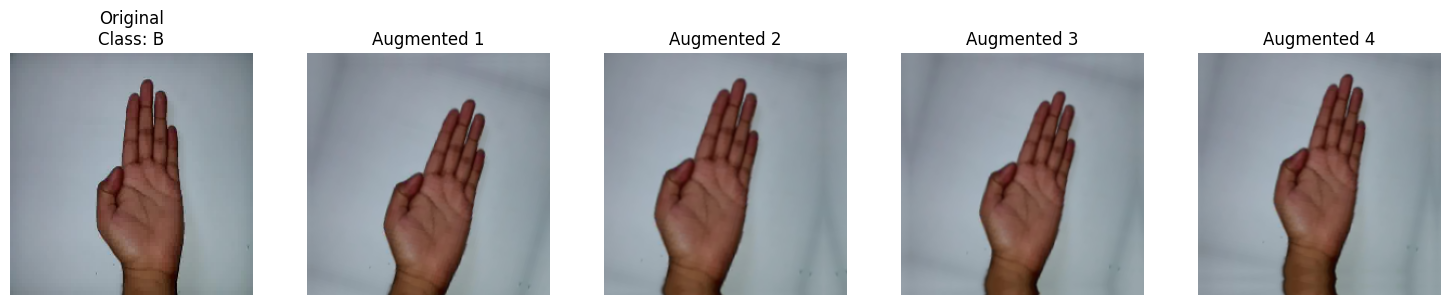

In [31]:
# Take one batch from the training dataset
sample_images, sample_labels = next(iter(train_dataset))

# Select the first image from the batch
original_image = sample_images[0]
original_label = sample_labels[0].numpy()

# Create augmented versions
augmented_images = [
    data_augmentation(
        tf.expand_dims(original_image, axis=0),
        training=True
    )[0].numpy()
    for _ in range(4)
]

# Display original and augmented images
plt.figure(figsize=(15, 3))

plt.subplot(1, 5, 1)
plt.imshow(original_image.numpy())
plt.title(f"Original\nClass: {index_to_class[original_label]}")
plt.axis("off")

for i, augmented_image in enumerate(augmented_images, start=2):
    plt.subplot(1, 5, i)
    plt.imshow(np.clip(augmented_image, 0, 1))
    plt.title(f"Augmented {i-1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

The visualization was used to compare the original training image with four augmented versions generated using the data augmentation pipeline.

The original image represents **class B**. The augmented images show small variations in the appearance and positioning of the same hand sign.

The augmented samples show changes in the hand's orientation, position, and apparent scale while retaining the main visual structure of the original hand sign. No horizontal flipping was applied.

This confirms that the selected augmentation operations are producing controlled variations rather than completely changing the underlying sign pattern.

**Result:** The data augmentation pipeline produces visually varied versions of the original **class B** image while preserving its main hand-sign structure.

## 2.14 Final Preprocessing Summary

The image preprocessing stage has prepared the cleaned Indian Sign Language dataset for deep learning model development.

The following preprocessing operations have been completed:

1. The identified duplicate image was removed.
2. The cleaned dataset contains **4,971 images**.
3. The images were divided into training, validation, and testing datasets.
4. The final split contains **3,976 training images, 497 validation images, and 498 testing images**.
5. All **24 classes** are represented across the datasets.
6. A fixed class-to-index mapping was created for the 24 classes.
7. Images are loaded using a memory-efficient TensorFlow `tf.data` pipeline.
8. Images are resized to **224 × 224 pixels**.
9. Images are processed as RGB images.
10. Pixel values are normalized to the **0–1 range**.
11. Images are processed in batches of **32**.
12. The training dataset contains **125 batches per epoch**, while validation and testing contain **16 batches each**.
13. Data augmentation using rotation, zoom, and translation was created and visually verified.
14. Horizontal flipping was intentionally excluded.

The prepared TensorFlow datasets can now be used for model development and training.

In [32]:
print("===== FINAL PREPROCESSING SUMMARY =====")
print("Total Clean Images:", len(image_df_clean))
print("Number of Classes:", len(classes))
print("Training Images:", len(train_df))
print("Validation Images:", len(val_df))
print("Testing Images:", len(test_df))
print("Image Size:", f"{IMG_HEIGHT} x {IMG_WIDTH}")
print("Batch Size:", BATCH_SIZE)
print("Training Batches:", train_batches)
print("Validation Batches:", val_batches)
print("Testing Batches:", test_batches)
print("Normalization Range: 0 to 1")
print("Data Augmentation: Enabled")
print("=======================================")

===== FINAL PREPROCESSING SUMMARY =====
Total Clean Images: 4971
Number of Classes: 24
Training Images: 3976
Validation Images: 497
Testing Images: 498
Image Size: 224 x 224
Batch Size: 32
Training Batches: 125
Validation Batches: 16
Testing Batches: 16
Normalization Range: 0 to 1
Data Augmentation: Enabled


### Observation

The final preprocessing stage was completed successfully.

The cleaned dataset contains **4,971 images** belonging to **24 classes**. The images were divided into **3,976 training images, 497 validation images, and 498 testing images**.

All images are processed at a fixed size of **224 × 224 pixels** with a batch size of **32**. The TensorFlow pipeline contains **125 training batches, 16 validation batches, and 16 testing batches**.

The preprocessing pipeline normalizes pixel values to the **0–1 range** and includes data augmentation for the training process.

The dataset is now prepared using a memory-efficient batch-based pipeline and can be used for developing the classification model.

**Result:** Image preprocessing and dataset preparation were successfully completed for the Indian Sign Language recognition task.

# 3. Model Development

The next stage of the project is to develop a deep learning model for Indian Sign Language image classification.

Since the input data consists of images, a Convolutional Neural Network (CNN) will be used. CNNs are well suited for image classification because convolutional layers can learn spatial and visual features from images.

The model will progressively learn features through multiple convolutional layers. Earlier layers can learn simpler visual patterns, while deeper layers can learn more complex patterns related to the hand signs.

The model development process will include:

1. Designing the CNN architecture.
2. Compiling the model with an appropriate optimizer and loss function.
3. Calculating class weights to handle the variation in class-wise image counts.
4. Training the CNN model.
5. Monitoring training and validation performance.
6. Evaluating the trained model using the unseen test dataset.
7. Analysing the classification results using performance metrics and a confusion matrix.

## 3.1 CNN Architecture Design

A Convolutional Neural Network will be created to classify the **24 Indian Sign Language classes**.

The architecture will contain multiple convolutional and pooling layers followed by a Global Average Pooling layer and fully connected layers.

The architecture will use:

- **Input layer:** 224 × 224 × 3 RGB image
- **Data augmentation:** Applied during training
- **Convolutional layers:** Learn visual features from the hand-sign images
- **MaxPooling layers:** Reduce the spatial dimensions of feature maps
- **Global Average Pooling:** Convert feature maps into a compact feature representation
- **Dense layer:** Learn higher-level classification patterns
- **Dropout:** Reduce the risk of overfitting
- **Output layer:** 24 neurons with Softmax activation, one for each sign class

The data augmentation layers will be included inside the model so that augmentation is active during training while validation and testing data remain unchanged.

In [33]:
model = models.Sequential([

    # Input layer
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Data augmentation
    data_augmentation,

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 4
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Feature aggregation
    layers.GlobalAveragePooling2D(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Dropout for regularization
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(len(classes), activation="softmax")
])

print("CNN model created successfully!")

CNN model created successfully!


### Observation

The Convolutional Neural Network (CNN) model was successfully created without any errors.

The model is configured to accept RGB images with an input size of **224 × 224 × 3** and contains the previously defined data augmentation layers followed by convolutional feature-extraction layers.

The architecture also includes pooling, Global Average Pooling, a dense layer, dropout regularization, and a final Softmax output layer for the **24 Indian Sign Language classes**.

The model is now ready for architecture inspection and compilation.

**Result:** The CNN model was successfully created for classifying the **24 Indian Sign Language classes**.

## 3.2 CNN Model Architecture Summary

The complete CNN architecture will be displayed to verify the sequence of layers, output shapes, and number of trainable parameters.

The model summary will help us understand how the input image is transformed through the convolutional and pooling layers before reaching the final classification layer.

The parameter count will also provide an indication of the model size and complexity before training begins.

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,408 (1.62 MB)

 Trainable params: 424,408 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

### Observation

The CNN architecture was inspected using `model.summary()` to verify the model layers, output shapes, and parameter counts.

The model accepts input images of size **224 × 224 × 3**. The convolutional layers progressively increase the number of feature maps from **32 to 256**, while the MaxPooling layers reduce the spatial dimensions of the feature maps.

The `GlobalAveragePooling2D` layer converts the final feature maps into a compact **256-dimensional** feature representation. This is followed by a **128-neuron Dense layer**, a **Dropout layer**, and the final **24-neuron Softmax layer** corresponding to the 24 sign classes.

The model contains a total of **424,408 parameters**, all of which are trainable. The model size shown in the summary is approximately **1.62 MB**.

There are **0 non-trainable parameters**, meaning all model parameters can be updated during the training process.

**Result:** The CNN contains **424,408 trainable parameters** and is configured to produce predictions for all **24 Indian Sign Language classes**.

## 3.3 Model Compilation

Before training, the CNN model must be compiled by specifying the optimization algorithm, loss function, and evaluation metrics.

The **Adam optimizer** will be used to update the model weights during training.

Since the class labels have been converted into integer indices from **0 to 23**, `SparseCategoricalCrossentropy` will be used as the loss function. This loss function is appropriate for multi-class classification when the target labels are represented as integers.

**Accuracy** will be used as the primary evaluation metric to track the proportion of correctly classified images during training and validation.

The model will then be ready for the training stage.

In [35]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully!")
print("Optimizer: Adam")
print("Learning Rate: 0.001")
print("Loss Function: Sparse Categorical Crossentropy")
print("Metric: Accuracy")

Model compiled successfully!
Optimizer: Adam
Learning Rate: 0.001
Loss Function: Sparse Categorical Crossentropy
Metric: Accuracy


### Observation

The CNN model was successfully compiled without errors.

The **Adam optimizer** was configured with a learning rate of **0.001** to update the model weights during training.

The **Sparse Categorical Crossentropy** loss function was selected because the target classes are represented using integer indices from **0 to 23**.

**Accuracy** was selected as the evaluation metric to measure the proportion of correctly classified images.

The compiled model is now ready for the training preparation stage.

**Result:** The CNN model was successfully compiled using **Adam**, **Sparse Categorical Crossentropy**, and **Accuracy**.

## 3.4 Class Weight Calculation

The training dataset contains different numbers of images for the 24 Indian Sign Language classes.

To reduce the effect of this class imbalance during model training, class weights will be calculated using the training labels.

Classes with fewer training samples will receive a higher weight, while classes with more training samples will receive a relatively lower weight.

These weights will later be supplied to the model during training so that errors from less-represented classes receive appropriate importance.

The class weights will be calculated only from the training dataset because validation and testing data should not influence the training process.

In [36]:
# Calculate class weights using only the training labels
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(classes)),
    y=train_labels
)

class_weights = {
    class_index: weight
    for class_index, weight in enumerate(class_weight_values)
}

class_weight_df = pd.DataFrame({
    "Class": classes,
    "Class Index": np.arange(len(classes)),
    "Training Images": train_class_counts.values,
    "Class Weight": class_weight_values
})

display(class_weight_df)

print("Number of Class Weights:", len(class_weights))
print("Minimum Class Weight:", class_weight_values.min())
print("Maximum Class Weight:", class_weight_values.max())

,Class,Class Index,Training Images,Class Weight
0,A,0,193,0.858377
1,B,1,207,0.800322
2,C,2,197,0.840948
3,D,3,118,1.403955
4,E,4,194,0.853952
5,F,5,181,0.915285
6,G,6,193,0.858377
7,H,7,93,1.781362
8,I,8,142,1.166667
9,K,9,196,0.845238


Number of Class Weights: 24
Minimum Class Weight: 0.8003220611916264
Maximum Class Weight: 1.7813620071684588


### Observation

Class weights were calculated using only the training dataset to address the variation in the number of images available for each sign class.

A total of **24 class weights** were generated, corresponding to the 24 Indian Sign Language classes.

The calculated class weights range from **0.800322** to **1.781362**. The **B** class has the minimum class weight of **0.800322**, while the **H** class has the maximum class weight of **1.781362**.

The higher weight assigned to class **H** reflects its lower number of training images (**93**), while classes with relatively more training images receive lower weights.

These class weights will be provided during model training so that the variation in class representation is taken into account when calculating the training loss.

**Result:** Class weights were successfully calculated for all **24 classes**, with values ranging from **0.800322 to 1.781362**.

## 3.5 Training Callbacks

Training callbacks will be used to monitor the model during the training process and improve the efficiency of model development.

The following callbacks will be used:

1. **EarlyStopping**
   
   Training will stop if the validation loss does not improve for a specified number of epochs. The best model weights will be restored after training.

2. **ReduceLROnPlateau**
   
   If the validation loss stops improving, the learning rate will be reduced. This allows the optimizer to make smaller weight updates when the model reaches a plateau.

3. **ModelCheckpoint**
   
   The model with the best validation accuracy will be saved so that the best-performing version can be used later for evaluation.

These callbacks help avoid unnecessary training and provide a mechanism for retaining the best model obtained during training.

In [37]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_isl_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

print("Training callbacks configured successfully!")
print("EarlyStopping: Enabled")
print("ReduceLROnPlateau: Enabled")
print("ModelCheckpoint: Enabled")

Training callbacks configured successfully!
EarlyStopping: Enabled
ReduceLROnPlateau: Enabled
ModelCheckpoint: Enabled


### Observation

The training callbacks were configured successfully without errors.

Three callbacks have been enabled for the training process:

- **EarlyStopping** will monitor validation loss and stop training when further improvement is not observed, while restoring the best model weights.
- **ReduceLROnPlateau** will reduce the learning rate when validation loss stops improving.
- **ModelCheckpoint** will save the model with the best validation accuracy.

These callbacks will help control the training process and retain the best-performing model based on validation performance.

**Result:** All three training callbacks were successfully configured and are ready to be used during model training.

## 3.6 Model Training

The CNN model will now be trained using the prepared training dataset.

The model will be trained for a maximum of **20 epochs**. During each epoch, the model will process the training images in batches and update its learnable parameters based on the training loss.

The validation dataset will be evaluated after each epoch to monitor how well the model performs on images that were not used to update the model weights.

The previously calculated class weights will be used during training to account for the variation in the number of training images among the 24 classes.

The configured callbacks will monitor validation performance, adjust the learning rate when necessary, stop training if further improvement is not observed, and save the best-performing model.

Training progress will be displayed for every epoch.

In [38]:
EPOCHS = 20

print("Starting CNN training...")
print("Maximum Epochs:", EPOCHS)
print("Training Batches per Epoch:", train_batches)
print("Validation Batches per Epoch:", val_batches)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\nCNN training completed!")

Starting CNN training...
Maximum Epochs: 20
Training Batches per Epoch: 125
Validation Batches per Epoch: 16
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.0402 - loss: 3.1900
Epoch 1: val_accuracy improved from None to 0.08249, saving model to best_isl_cnn.keras

Epoch 1: finished saving model to best_isl_cnn.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 712s 6s/step - accuracy: 0.0493 - loss: 3.1306 - val_accuracy: 0.0825 - val_loss: 2.9433 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.0941 - loss: 2.8202
Epoch 2: val_accuracy improved from 0.08249 to 0.12877, saving model to best_isl_cnn.keras

Epoch 2: finished saving model to best_isl_cnn.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 754s 6s/step - accuracy: 0.1054 - loss: 2.7176 - val_accuracy: 0.1288 - val_loss: 2.4906 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1338 - loss: 2.5511
Epoch 3: val_accuracy improved from 0.12877 to 0.18913, saving mo

### Observation

The CNN model was trained for the full **20 epochs** using the training dataset containing **3,976 images** distributed across **125 batches per epoch**.

During training, the model showed a clear improvement in training performance. The training accuracy increased from **4.93% in Epoch 1** to **83.78% in Epoch 20**, while the training loss decreased from **3.1306** to **0.4835**.

Validation performance also improved substantially during training. The validation accuracy increased from **8.25% in Epoch 1** to a best value of **89.74% in Epoch 19**. The validation loss reached its lowest recorded value of **0.3016** in Epoch 19.

The validation accuracy did not improve in several epochs, so the `ReduceLROnPlateau` callback reduced the learning rate during training. The learning rate was reduced from **0.001** to **0.0005**, then to **0.00025**, and finally to **0.000125**.

The `ModelCheckpoint` callback saved the model whenever validation accuracy improved. The best validation accuracy of **89.74%** was obtained in **Epoch 19**, and the model weights from this epoch were restored after training.

Although Epoch 20 completed, its validation accuracy decreased to **81.69%** compared with the best **89.74%** achieved in Epoch 19. Therefore, restoring the Epoch 19 weights ensures that the best validation-performing model is retained.

**Result:** The CNN completed all **20 epochs**, achieving a best validation accuracy of **89.74% in Epoch 19** with a validation loss of **0.3016**. The best model weights were restored automatically.

## 3.7 Training and Validation Performance

The training history recorded during model training will be analysed using accuracy and loss curves.

Two plots will be created:

1. **Training vs Validation Accuracy**
   
   This plot shows how classification accuracy changed across the training epochs.

2. **Training vs Validation Loss**
   
   This plot shows how the model's prediction error changed across the training epochs.

These curves help analyse the learning behaviour of the CNN and identify whether the model continued to improve or showed signs of overfitting during training.

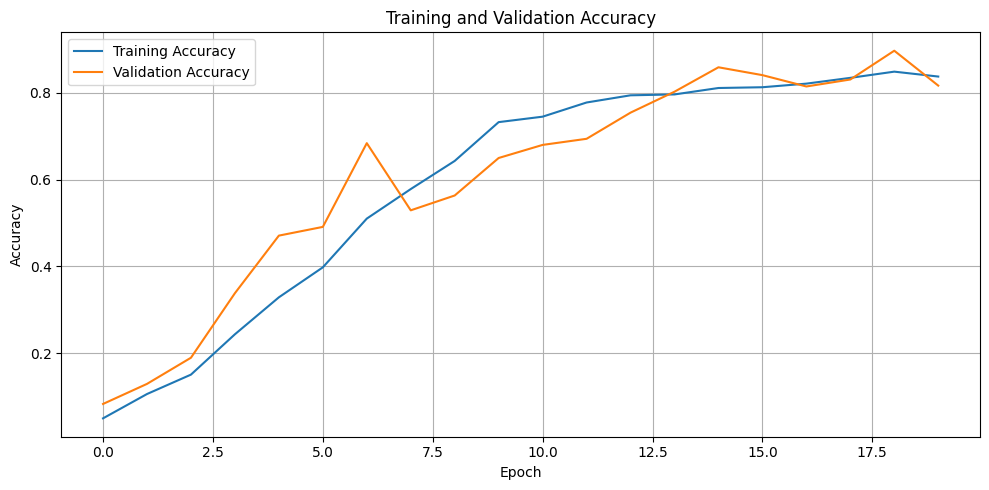

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

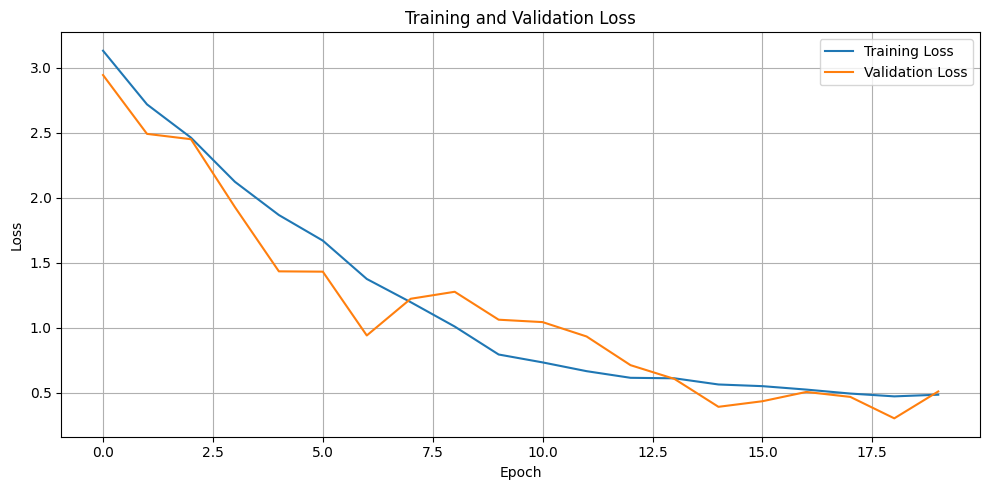

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

The training and validation accuracy curves show that the CNN learned progressively throughout the training process.

The training accuracy increased steadily from approximately **5% in the first epoch** to approximately **84% by the final epoch**. The validation accuracy also improved overall, reaching its highest value of approximately **89.74% in Epoch 19**.

The validation accuracy shows some fluctuations during training. A noticeable improvement occurs from Epoch 6 to Epoch 7, followed by further improvement in the later epochs. The highest validation accuracy was achieved in Epoch 19, while the validation accuracy decreased in Epoch 20.

The training and validation loss curves show an overall decreasing trend. Training loss decreased from approximately **3.13** at the beginning to approximately **0.48** by the final epoch. Validation loss also decreased substantially and reached its lowest recorded value of **0.3016 in Epoch 19** before increasing to **0.5084 in Epoch 20**.

The difference between training and validation performance varies across the epochs. The best validation performance occurring before the final epoch indicates that Epoch 19 produced the strongest validation result, which is consistent with the model checkpoint restoring the weights from that epoch.

**Result:** The learning curves show substantial improvement in both training and validation performance, with the best validation performance occurring at **Epoch 19**, where validation accuracy reached **89.74%** and validation loss reached **0.3016**.

## 3.8 Final Model Evaluation on Test Dataset

The trained CNN model will now be evaluated using the independent testing dataset.

The testing dataset contains images that were not used during model training or validation. Therefore, test performance provides an estimate of how well the trained model can generalize to unseen Indian Sign Language images.

The model will be evaluated using:

- Test loss
- Test accuracy

The testing dataset contains **498 images distributed across the 24 sign classes**.

The evaluation will use the model weights restored from the best validation-performing epoch.

In [41]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("\n===== TEST SET EVALUATION =====")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)
print("===============================")

16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.8896 - loss: 0.2750

===== TEST SET EVALUATION =====
Test Loss: 0.27502548694610596
Test Accuracy: 0.8895582556724548
Test Accuracy (%): 88.95582556724548


### Observation

The trained CNN model was evaluated on the independent testing dataset containing **498 images**.

The evaluation was completed in **16 batches**, and the model achieved a **test accuracy of 88.96%** with a **test loss of 0.2750**.

The test accuracy of **88.96%** indicates that the trained model correctly classified a high proportion of the unseen test images across the 24 Indian Sign Language classes.

The test loss of **0.2750** represents the classification loss calculated on the testing dataset.

The test accuracy is also close to the best validation accuracy of **89.74%**, indicating that the model maintained similar performance when evaluated on the independent testing data.

**Result:** The CNN achieved a **test accuracy of 88.96%** and a **test loss of 0.2750** on the unseen testing dataset.

## 3.9 Generate Predictions on Test Dataset

The trained CNN model will be used to generate predictions for every image in the testing dataset.

The model produces a probability value for each of the 24 classes. The class with the highest predicted probability will be selected as the final predicted class.

The predicted numerical labels will then be converted back into their corresponding Indian Sign Language class names using the previously created `index_to_class` mapping.

These predictions will be used in the following evaluation steps to generate a detailed classification report and confusion matrix.

In [42]:
# Generate predictions for the complete test dataset
y_prob = model.predict(
    test_dataset,
    verbose=1
)

# Convert probabilities to predicted class indices
y_pred = np.argmax(y_prob, axis=1)

# Actual labels
y_true = test_labels

# Convert numerical indices back to class names
y_pred_labels = [
    index_to_class[index]
    for index in y_pred
]

y_true_labels = [
    index_to_class[index]
    for index in y_true
]

print("\n===== PREDICTION SUMMARY =====")
print("Number of Test Samples:", len(y_true))
print("Number of Predictions:", len(y_pred))
print("Number of Classes:", len(classes))
print("==============================")

16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step

===== PREDICTION SUMMARY =====
Number of Test Samples: 498
Number of Predictions: 498
Number of Classes: 24


### Observation

Predictions were successfully generated for the complete testing dataset using the trained CNN model.

The testing dataset contains **498 samples**, and the model generated exactly **498 predictions**. This confirms that every test image received a corresponding predicted class.

The model produces predictions across the **24 Indian Sign Language classes**, and the numerical predictions were converted back into their corresponding class labels using the `index_to_class` mapping.

The generated predictions and actual test labels are now ready for detailed performance analysis.

**Result:** Predictions were successfully generated for all **498 test images across 24 classes**.

## 3.10 Classification Report

A detailed classification report will be generated using the actual and predicted labels from the testing dataset.

The report will provide the following metrics for each of the 24 sign classes:

- **Precision:** Measures how many of the images predicted as a particular class actually belong to that class.
- **Recall:** Measures how many images belonging to a particular class were correctly identified.
- **F1-score:** Provides a combined measure of precision and recall.
- **Support:** Shows the number of actual test samples belonging to each class.

The report will also provide overall and averaged performance across all 24 classes.

In [43]:
report = classification_report(
    y_true_labels,
    y_pred_labels,
    labels=classes,
    target_names=classes,
    digits=4
)

print("===== CLASSIFICATION REPORT =====")
print(report)
print("=================================")

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000        25
           B     0.7667    0.8846    0.8214        26
           C     0.9615    1.0000    0.9804        25
           D     0.8750    1.0000    0.9333        14
           E     0.7353    1.0000    0.8475        25
           F     0.8235    0.6087    0.7000        23
           G     1.0000    1.0000    1.0000        24
           H     1.0000    1.0000    1.0000        11
           I     1.0000    1.0000    1.0000        18
           K     0.9615    1.0000    0.9804        25
           L     0.7143    0.8333    0.7692        18
           M     0.8148    0.9167    0.8627        24
           N     0.9000    0.7500    0.8182        24
           O     0.9545    0.9130    0.9333        23
           P     0.9600    1.0000    0.9796        24
           Q     1.0000    1.0000    1.0000        21
           R     1.0000    0.9524    0.9756    

### Observation

The classification report was generated using the actual and predicted labels for all **498 test images** across the **24 Indian Sign Language classes**.

The model achieved an overall **accuracy of 88.96%**. The **macro-average precision is 0.8951**, the **macro-average recall is 0.8710**, and the **macro-average F1-score is 0.8620**. The weighted-average precision, recall, and F1-score are **0.9015, 0.8896, and 0.8813**, respectively.

Several classes achieved very strong performance. Classes **A, G, H, I, and Q** achieved a precision, recall, and F1-score of **1.0000**. Classes **C, K, and P** also achieved F1-scores close to 0.98.

The lowest F1-scores were observed for **V (0.2857)** and **W (0.4211)**. Class **V** had a recall of only **0.1667**, while class **W** had a recall of **0.3077**. Class **F** also showed comparatively lower performance with an F1-score of **0.7000** and recall of **0.6087**.

The results show that the CNN performs very well for several sign classes, while some classes are more difficult for the model to recognize correctly.

**Result:** The classification report confirms an overall test accuracy of **88.96%**, with strong performance for many classes and comparatively weaker recognition for classes such as **V, W, and F**.

## 3.11 Confusion Matrix

A confusion matrix will be generated to analyse the prediction behaviour of the CNN across all 24 Indian Sign Language classes.

Each row represents the actual class, while each column represents the predicted class.

The diagonal values represent correctly classified images. Values outside the diagonal represent misclassified images and show which classes are being confused with one another.

The confusion matrix will help identify specific class-level prediction errors that cannot be understood from the overall accuracy alone.

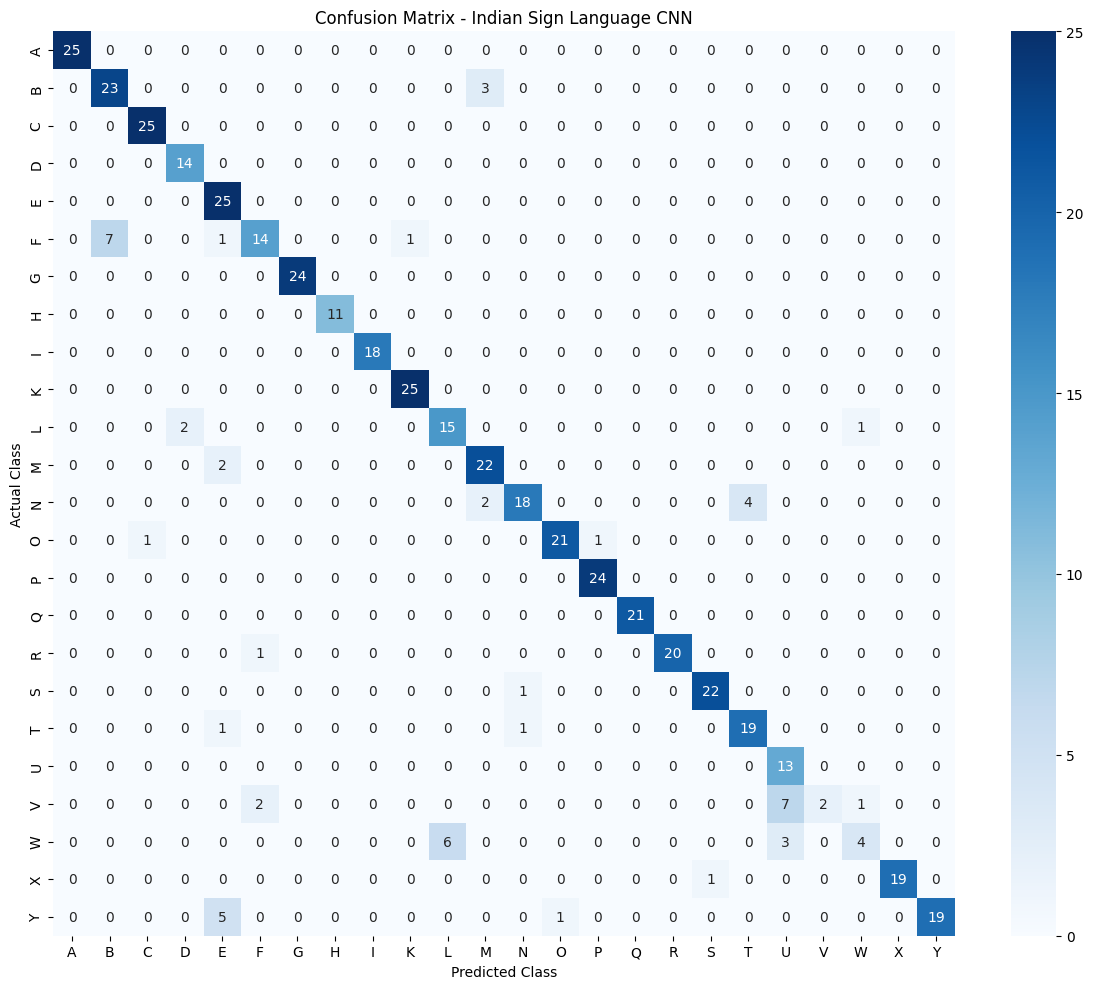

In [44]:
cm = confusion_matrix(
    y_true_labels,
    y_pred_labels,
    labels=classes
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix - Indian Sign Language CNN")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

### Observation

The confusion matrix was generated to examine the class-wise prediction behaviour of the CNN across the **24 Indian Sign Language classes**.

The diagonal of the confusion matrix represents correctly classified images. A large number of values are concentrated along the diagonal, which is consistent with the overall test accuracy of **88.96%**.

Several classes were classified completely correctly in the test set. For example, **A, C, D, G, H, I, K, P, and Q** have all their test samples correctly classified according to the confusion matrix.

Some specific misclassification patterns were also observed:

- **F → B:** 7 images belonging to class F were predicted as B.
- **W → L:** 6 images belonging to class W were predicted as L.
- **N → O:** 4 images belonging to class N were predicted as O.
- **V → U:** 7 images belonging to class V were predicted as U.
- **V → W:** 2 images belonging to class V were predicted as W.
- **W → U:** 3 images belonging to class W were predicted as U.
- **Y → E:** 5 images belonging to class Y were predicted as E.

These misclassification patterns help explain the lower recall observed for classes such as **V, W, F, N, and Y** in the classification report.

The confusion matrix therefore provides more detailed information than overall accuracy by showing exactly where the model makes classification errors.

**Result:** The CNN correctly classifies most test samples, while the major observed confusion patterns involve classes such as **V, W, F, N, and Y**.

## 3.12 Save the Final Trained Model

The trained CNN model will be saved so that it can be reused later without retraining the model from the beginning.

The model contains the learned weights, CNN architecture, data augmentation layers, and classification configuration.

Since `EarlyStopping` restored the weights from the best validation-performing epoch, the model being saved represents the best validation performance obtained during the training process.

The saved model can later be loaded for prediction on new Indian Sign Language images or integrated into an application.

In [45]:
  FINAL_MODEL_PATH = "ISL_CNN_Final.keras"

model.save(FINAL_MODEL_PATH)

print("Final model saved successfully!")
print("Model Path:", FINAL_MODEL_PATH)
print("Best Validation Accuracy:", max(history.history["val_accuracy"]))
print("Test Accuracy:", test_accuracy)

Final model saved successfully!
Model Path: ISL_CNN_Final.keras
Best Validation Accuracy: 0.8973842859268188
Test Accuracy: 0.8895582556724548


### Observation

The trained CNN model was successfully saved as **`ISL_CNN_Final.keras`**.

The saved model corresponds to the best validation-performing weights obtained during training. The best validation accuracy recorded during training was **89.74%**, while the final test accuracy was **88.96%**.

Saving the model allows it to be reused for future predictions without having to repeat the complete training process.

**Result:** The final trained Indian Sign Language CNN model was successfully saved as **`ISL_CNN_Final.keras`**, with a best validation accuracy of **89.74%** and test accuracy of **88.96%**.

## 3.13 Model Loading Verification

The saved CNN model will be loaded from the `.keras` file to verify that the model was saved correctly and can be restored for future use.

The loaded model will be checked by displaying its architecture summary and comparing its output configuration with the original model.

Successful loading confirms that the trained model can be reused without performing the training process again.

In [46]:
loaded_model = tf.keras.models.load_model("ISL_CNN_Final.keras")

print("Saved model loaded successfully!")
print("Loaded Model Input Shape:", loaded_model.input_shape)
print("Loaded Model Output Shape:", loaded_model.output_shape)

Saved model loaded successfully!
Loaded Model Input Shape: (None, 224, 224, 3)
Loaded Model Output Shape: (None, 24)


### Observation

The saved CNN model was successfully loaded from the `ISL_CNN_Final.keras` file without errors.

The loaded model has an input shape of **(None, 224, 224, 3)**, confirming that it accepts RGB images with a resolution of **224 × 224 pixels**.

The output shape is **(None, 24)**, confirming that the model produces one prediction probability for each of the **24 Indian Sign Language classes**.

The successful loading confirms that the trained model can be restored and reused without retraining.

**Result:** The saved CNN model was successfully restored with the expected **224 × 224 × 3 input** and **24-class output** configuration.

## 3.14 Verify Prediction Using Loaded Model

A sample batch from the testing dataset will be passed through the loaded CNN model to verify that the restored model can generate predictions correctly.

The prediction output will contain a probability score for each of the 24 Indian Sign Language classes.

The class with the highest probability will be selected as the predicted class. The predicted class will then be compared with the actual class label from the testing dataset.

The prediction confidence will also be displayed to understand how strongly the model supports its predicted class.

In [48]:
# Take one batch from the test dataset
sample_test_images, sample_test_labels = next(iter(test_dataset))

# Generate predictions using the loaded model
sample_predictions = loaded_model.predict(
    sample_test_images,
    verbose=0
)

# Select the first test image
sample_index = 0

# Get predicted class and confidence
predicted_index = np.argmax(sample_predictions[sample_index])
predicted_class = index_to_class[predicted_index]
prediction_confidence = sample_predictions[sample_index][predicted_index]

# Get actual class
actual_index = sample_test_labels[sample_index].numpy()
actual_class = index_to_class[actual_index]

print("===== SAMPLE PREDICTION =====")
print("Actual Class:", actual_class)
print("Predicted Class:", predicted_class)
print("Prediction Confidence:", prediction_confidence)
print("Prediction Confidence (%):", prediction_confidence * 100)
print("=============================")

===== SAMPLE PREDICTION =====
Actual Class: K
Predicted Class: K
Prediction Confidence: 0.95746136
Prediction Confidence (%): 95.74614


### Observation

The loaded CNN model was tested on a sample image from the testing dataset to verify that the saved model can generate predictions correctly.

For the selected test image, the **actual class was K** and the model also predicted **K**.

The model assigned a prediction confidence of **95.74614%** to the predicted class.

Since the predicted class matches the actual class, the sample image was correctly classified by the loaded model.

**Result:** The loaded CNN correctly predicted the sample test image as **class K** with a confidence of **95.75%**.

## 3.15 Single-Image Prediction

A single-image prediction function will be created to demonstrate the practical use of the trained Indian Sign Language recognition model.

The function will accept an image path and perform the same preprocessing used during model development:

1. Read the image.
2. Convert it to RGB.
3. Resize it to **224 × 224 pixels**.
4. Normalize the pixel values to the **0–1 range**.
5. Add a batch dimension.
6. Pass the image through the trained CNN.
7. Identify the class with the highest prediction probability.
8. Convert the numerical prediction back to the corresponding sign class.
9. Display the predicted class and confidence.

This function can later be used as the prediction component of an application or demonstration system.

In [49]:
def predict_single_image(image_path):
    # Load image
    image = Image.open(image_path).convert("RGB")

    # Resize image
    image_resized = image.resize((IMG_WIDTH, IMG_HEIGHT))

    # Convert to NumPy array
    image_array = np.array(image_resized, dtype=np.float32)

    # Normalize pixel values
    image_array = image_array / 255.0

    # Add batch dimension
    image_batch = np.expand_dims(image_array, axis=0)

    # Generate prediction
    prediction = loaded_model.predict(
        image_batch,
        verbose=0
    )

    # Get predicted class
    predicted_index = np.argmax(prediction[0])
    predicted_class = index_to_class[predicted_index]

    # Get confidence
    confidence = prediction[0][predicted_index]

    # Display image
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"Predicted Sign: {predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.axis("off")
    plt.show()

    print("===== SINGLE IMAGE PREDICTION =====")
    print("Image:", image_path)
    print("Predicted Sign:", predicted_class)
    print("Confidence:", f"{confidence * 100:.2f}%")
    print("===================================")

    return predicted_class, confidence


print("Single-image prediction function created successfully!")

Single-image prediction function created successfully!


### Observation

The single-image prediction function was created successfully without errors.

The function is designed to accept an individual image path, apply the same basic preprocessing steps used during model development, and pass the processed image through the saved CNN model.

It will return the predicted Indian Sign Language class along with the model's prediction confidence and display the input image with the prediction.

**Result:** The single-image prediction function is ready to be used for testing individual Indian Sign Language images.

## 3.16 Test Single-Image Prediction

The single-image prediction function will be tested using one image from the independent testing dataset.

The actual class is known from the test DataFrame, allowing the model's predicted class to be compared with the true class.

This provides a practical demonstration of how the trained Indian Sign Language recognition model can classify an individual image.

Actual Class: K
Image Path: /content/ISL_Dataset/Data/K/088.jpg


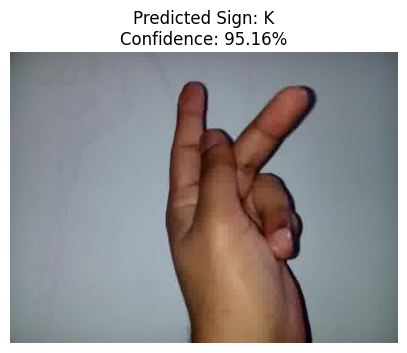

===== SINGLE IMAGE PREDICTION =====
Image: /content/ISL_Dataset/Data/K/088.jpg
Predicted Sign: K
Confidence: 95.16%


In [50]:
# Select one image from the test dataset
sample_image_path = test_df.iloc[0]["image_path"]
actual_class = test_df.iloc[0]["label"]

print("Actual Class:", actual_class)
print("Image Path:", sample_image_path)

# Predict the sign
predicted_class, confidence = predict_single_image(
    sample_image_path
)

### Observation

The trained CNN model was tested on an individual image from the testing dataset.

The selected image was:

`/content/ISL_Dataset/Data/K/088.jpg`

The actual class of the image is **K**, and the model also predicted the sign as **K**.

The model assigned a confidence of **95.16%** to the prediction. Therefore, the individual test image was correctly classified by the trained CNN.

The visualization also shows the input hand-sign image together with the predicted class and confidence score.

**Result:** The model correctly classified the individual test image as **K** with a confidence of **95.16%**.

# 4. Final Model Results

The Indian Sign Language recognition model was developed using a CNN trained on the cleaned dataset.

The final model was trained using **3,976 training images**, while **497 validation images** were used to monitor the training process and **498 independent test images** were used for final evaluation.

The model achieved a best validation accuracy of **89.74%** during training and a test accuracy of **88.96%** on the unseen test dataset.

The classification report and confusion matrix provided additional class-level information about the model's performance.

The trained model was also saved as `ISL_CNN_Final.keras` and successfully loaded again. A single-image prediction test correctly identified a test image belonging to class **K** with a confidence of **95.16%**.

In [51]:
final_results = pd.DataFrame({
    "Metric": [
        "Clean Dataset Images",
        "Number of Classes",
        "Training Images",
        "Validation Images",
        "Testing Images",
        "Image Size",
        "Batch Size",
        "CNN Parameters",
        "Best Validation Accuracy",
        "Test Accuracy",
        "Test Loss"
    ],
    "Value": [
        len(image_df_clean),
        len(classes),
        len(train_df),
        len(val_df),
        len(test_df),
        f"{IMG_HEIGHT} x {IMG_WIDTH}",
        BATCH_SIZE,
        model.count_params(),
        f"{max(history.history['val_accuracy']) * 100:.2f}%",
        f"{test_accuracy * 100:.2f}%",
        f"{test_loss:.4f}"
    ]
})

display(final_results)

,Metric,Value
0,Clean Dataset Images,4971
1,Number of Classes,24
2,Training Images,3976
3,Validation Images,497
4,Testing Images,498
5,Image Size,224 x 224
6,Batch Size,32
7,CNN Parameters,424408
8,Best Validation Accuracy,89.74%
9,Test Accuracy,88.96%


### Observation

The final model results were consolidated to provide an overall summary of the developed Indian Sign Language recognition system.

The cleaned dataset contains **4,971 images** belonging to **24 sign classes**. The dataset was divided into **3,976 training images, 497 validation images, and 498 testing images**.

The images were processed at **224 × 224 pixels** using a batch size of **32**. The developed CNN contains **424,408 trainable parameters**.

During training, the model achieved a best validation accuracy of **89.74%**. On the independent testing dataset, the model achieved a **test accuracy of 88.96%** with a **test loss of 0.2750**.

The results demonstrate that the developed CNN was able to learn the visual patterns present in the Indian Sign Language images and achieve close validation and testing performance.

**Result:** The final CNN achieved **88.96% test accuracy** on **498 unseen test images**, with a best validation accuracy of **89.74%**.

# 4.1 Project Conclusion

The Indian Sign Language Recognition project successfully developed a deep learning-based image classification system capable of recognizing **24 Indian Sign Language classes**.

The original dataset contained **4,972 images**. During data quality analysis, one exact duplicate image was identified and removed, resulting in a cleaned dataset containing **4,971 images**.

The cleaned dataset was divided into training, validation, and testing datasets using stratified splitting. The final split consisted of **3,976 training images, 497 validation images, and 498 testing images**.

A memory-efficient TensorFlow `tf.data` pipeline was developed to load and preprocess images in batches rather than storing the complete image dataset in memory. Images were processed as RGB images, resized to **224 × 224 pixels**, and normalized to the **0–1 range**.

Data augmentation using random rotation, zoom, and translation was incorporated into the CNN training process to introduce controlled variations in the training images.

A CNN architecture containing **424,408 trainable parameters** was developed and trained for a maximum of 20 epochs. Training callbacks were used to monitor validation performance, adjust the learning rate, and save the best-performing model.

The best validation accuracy achieved during training was **89.74% in Epoch 19**. The final model achieved a **test accuracy of 88.96%** with a test loss of **0.2750** on the independent testing dataset.

The classification report showed strong performance for several classes, while the confusion matrix identified specific classes where misclassification occurred, including **V, W, F, N, and Y**.

The trained model was saved as `ISL_CNN_Final.keras` and successfully loaded again. A single-image prediction test also correctly classified a test image from class **K** with a confidence of **95.16%**.

Overall, the project demonstrates the complete workflow of an image classification system, including dataset analysis, data cleaning, preprocessing, augmentation, CNN development, model training, evaluation, error analysis, model saving, and single-image prediction.

## 4.2 Multiple Test Image Prediction

To further demonstrate the practical performance of the trained model, predictions will be generated for multiple randomly selected images from the independent testing dataset.

For each selected image, the following information will be displayed:

- Actual class
- Predicted class
- Prediction confidence
- Whether the prediction is correct

A visual grid will also be generated to compare the actual and predicted classes.

This provides a broader demonstration of the model's prediction behaviour rather than relying on a single test image.

In [52]:
# Select 12 random images from the test dataset
sample_test_df = test_df.sample(
    n=12,
    random_state=42
).reset_index(drop=True)

prediction_results = []

for _, row in sample_test_df.iterrows():

    image_path = row["image_path"]
    actual_class = row["label"]

    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    image_resized = image.resize((IMG_WIDTH, IMG_HEIGHT))

    image_array = np.array(
        image_resized,
        dtype=np.float32
    ) / 255.0

    image_batch = np.expand_dims(
        image_array,
        axis=0
    )

    # Predict
    prediction = loaded_model.predict(
        image_batch,
        verbose=0
    )

    predicted_index = np.argmax(prediction[0])
    predicted_class = index_to_class[predicted_index]
    confidence = prediction[0][predicted_index]

    prediction_results.append({
        "Image": os.path.basename(image_path),
        "Actual": actual_class,
        "Predicted": predicted_class,
        "Confidence (%)": round(confidence * 100, 2),
        "Correct": actual_class == predicted_class
    })

prediction_results_df = pd.DataFrame(prediction_results)

display(prediction_results_df)

print("\nCorrect Predictions:",
      prediction_results_df["Correct"].sum())

print("Incorrect Predictions:",
      (~prediction_results_df["Correct"]).sum())

print("Sample Accuracy:",
      f"{prediction_results_df['Correct'].mean() * 100:.2f}%")

,Image,Actual,Predicted,Confidence (%),Correct
0,158.jpg,X,X,98.779999,True
1,028.jpg,B,B,99.360001,True
2,051.jpg,W,U,44.689999,False
3,028.jpg,T,T,79.690002,True
4,161.jpg,X,X,98.089996,True
5,044.jpg,V,V,40.770000,True
6,176.jpg,O,O,99.940002,True
7,135.jpg,L,L,78.629997,True
8,200.jpg,S,S,93.650002,True
9,160.jpg,B,B,98.470001,True



Correct Predictions: 11
Incorrect Predictions: 1
Sample Accuracy: 91.67%


### Observation

The trained CNN model was tested on **12 randomly selected images** from the independent testing dataset.

Out of the 12 selected images, **11 predictions were correct** and **1 prediction was incorrect**, resulting in a sample accuracy of **91.67%**.

The incorrect prediction occurred for image **051.jpg**, where the actual class was **W**, but the model predicted **U** with a confidence of **44.69%**.

The correctly classified samples included classes **X, B, T, V, O, L, S, F, and R**. Several of these predictions had high confidence, including **O at 99.94%**, **R at 99.41%**, **B at 99.36%**, and **X at 98.78%**.

The prediction for class **V** was correct despite having a relatively lower confidence of **40.77%**, showing that the model selected V as the highest-probability class even with relatively low confidence.

The sample accuracy of **91.67%** is based only on these 12 randomly selected images and should not be interpreted as the overall model accuracy. The overall test accuracy remains **88.96%**, calculated using all 498 test images.

**Result:** The model correctly classified **11 out of 12 randomly selected test images**, achieving a sample accuracy of **91.67%**.

## 4.3 Visualize Multiple Test Predictions

The 12 randomly selected test images used in the previous prediction analysis will now be displayed in a visual grid.

Each image will show:

- Actual class
- Predicted class
- Prediction confidence

This visualization provides an intuitive demonstration of the model's classification behaviour and makes it easier to identify correctly and incorrectly classified samples.

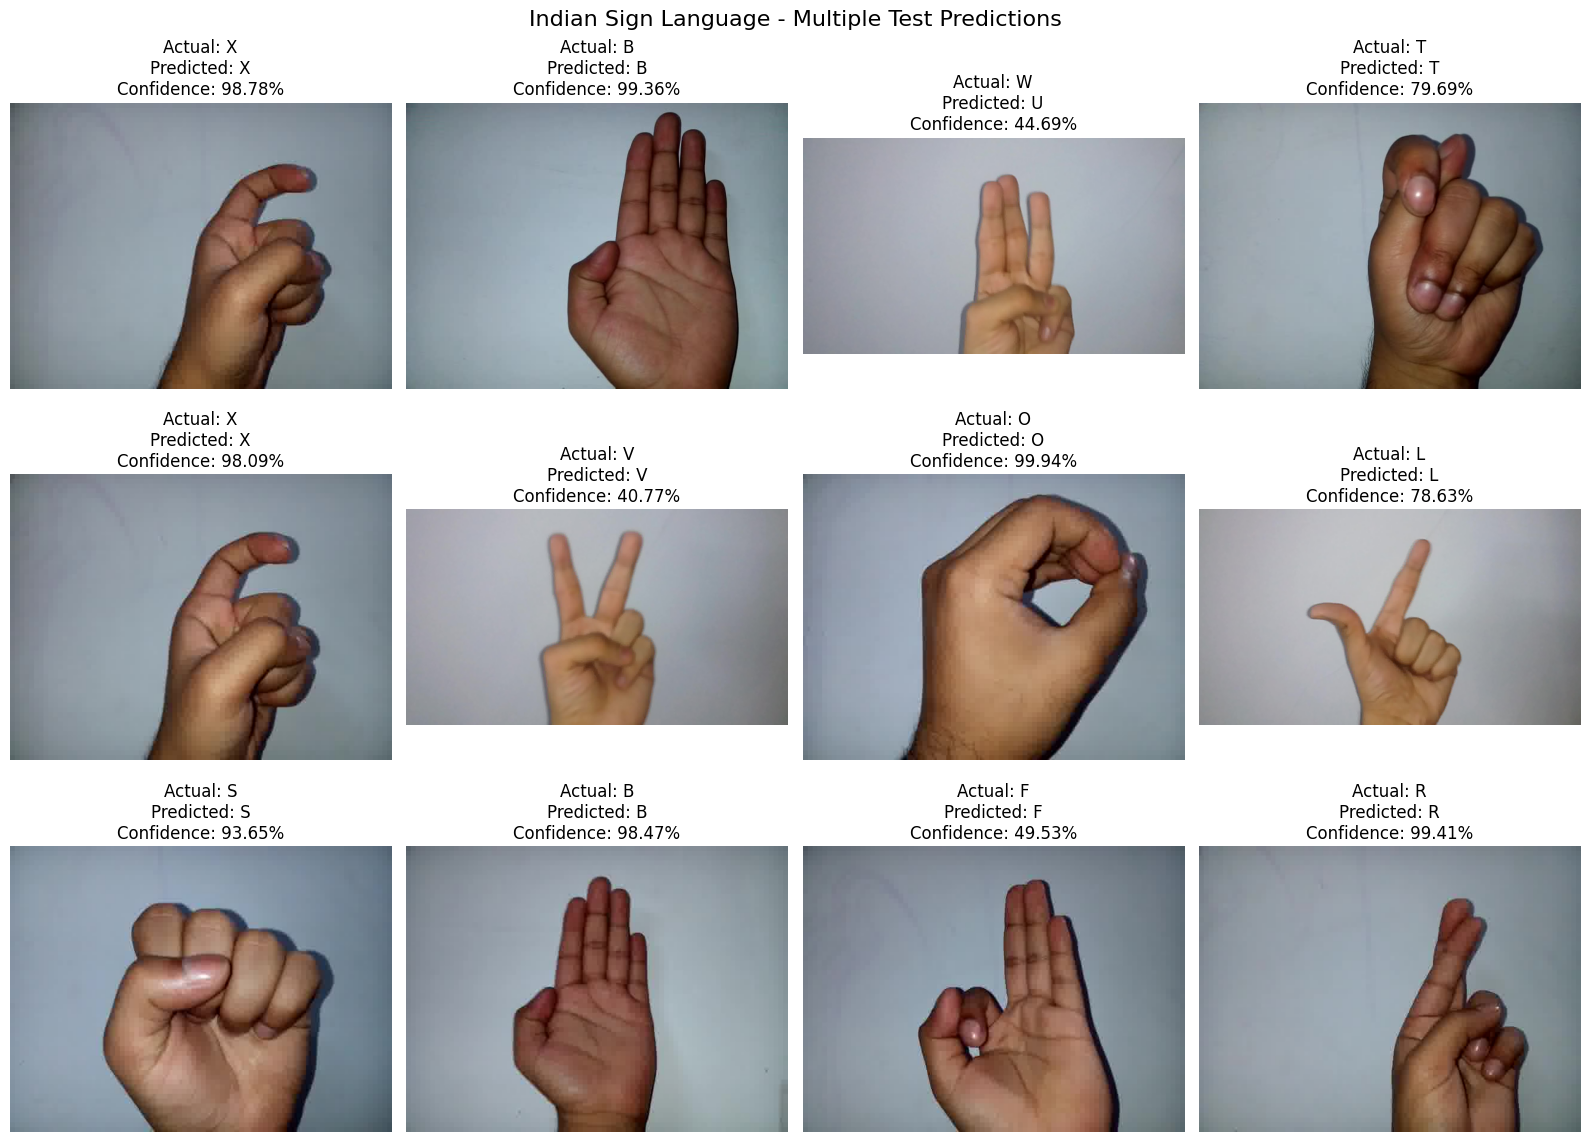

In [53]:
plt.figure(figsize=(16, 12))

for i, row in sample_test_df.iterrows():

    image_path = row["image_path"]
    actual_class = row["label"]

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocess
    image_resized = image.resize((IMG_WIDTH, IMG_HEIGHT))
    image_array = np.array(
        image_resized,
        dtype=np.float32
    ) / 255.0

    image_batch = np.expand_dims(
        image_array,
        axis=0
    )

    # Prediction
    prediction = loaded_model.predict(
        image_batch,
        verbose=0
    )

    predicted_index = np.argmax(prediction[0])
    predicted_class = index_to_class[predicted_index]
    confidence = prediction[0][predicted_index]

    # Display
    plt.subplot(3, 4, i + 1)
    plt.imshow(image)

    if actual_class == predicted_class:
        title = (
            f"Actual: {actual_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Confidence: {confidence * 100:.2f}%"
        )
    else:
        title = (
            f"Actual: {actual_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Confidence: {confidence * 100:.2f}%"
        )

    plt.title(title)
    plt.axis("off")

plt.suptitle(
    "Indian Sign Language - Multiple Test Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Observation

The 12 randomly selected test images were visualized together with their actual classes, predicted classes, and prediction confidence scores.

The visualization shows that the model correctly classified **11 of the 12 selected images**. Most of the correctly classified samples have relatively high prediction confidence, including the predictions for **X (98.78%), B (99.36%), O (99.94%), S (93.65%), and R (99.41%)**.

The only incorrect prediction in this sample was the image whose actual class was **W**. The model predicted it as **U** with a confidence of **44.69%**.

The visualization also demonstrates that the model can correctly recognize different hand-sign patterns across several classes, including X, B, T, V, O, L, S, F, and R.

The **91.67% sample accuracy** applies only to these 12 randomly selected images and is not the overall test accuracy. The overall evaluation on all **498 test images** achieved **88.96% accuracy**.

**Result:** The visual prediction analysis confirms that the model correctly classified **11 out of 12** selected test images, while also highlighting an example of confusion between **W and U**.

# 4.4 Final Project Summary

## Indian Sign Language Recognition Using CNN

The project successfully developed an image classification system for recognizing **24 Indian Sign Language classes** using a Convolutional Neural Network.

### Dataset

- Original images: **4,972**
- Duplicate images removed: **1**
- Final cleaned images: **4,971**
- Number of classes: **24**
- Training images: **3,976**
- Validation images: **497**
- Testing images: **498**

### Preprocessing

- Input image size: **224 × 224 × 3**
- Color format: **RGB**
- Pixel normalization: **0–1**
- Batch size: **32**
- Training batches: **125**
- Validation batches: **16**
- Testing batches: **16**
- Memory-efficient TensorFlow `tf.data` pipeline

### Data Augmentation

The training pipeline used:

- Random rotation
- Random zoom
- Random translation

Horizontal flipping was not used because changing the horizontal orientation of a hand sign may affect its visual representation.

### CNN Model

The developed CNN contains:

- Multiple convolutional layers
- MaxPooling layers
- Global Average Pooling
- Dense layer
- Dropout regularization
- 24-class Softmax output

Total trainable parameters: **424,408**

### Model Performance

- Best validation accuracy: **89.74%**
- Best validation epoch: **19**
- Test accuracy: **88.96%**
- Test loss: **0.2750**
- Macro F1-score: **0.8620**
- Weighted F1-score: **0.8813**

### Prediction Demonstration

The saved model was successfully loaded and used for individual image prediction.

A sample test image from class **K** was correctly predicted as **K** with **95.16% confidence**.

A separate demonstration using 12 randomly selected test images resulted in **11 correct predictions and 1 incorrect prediction**, giving a sample accuracy of **91.67%**.

### Final Outcome

The project demonstrates a complete deep learning workflow for Indian Sign Language recognition, including dataset exploration, duplicate detection, data cleaning, stratified dataset splitting, image preprocessing, data augmentation, CNN development, model training, performance evaluation, confusion matrix analysis, model saving, model loading, and single-image prediction.

The final trained model is saved as:

`ISL_CNN_Final.keras`